# Emergency Funds and Household Bill Payment: A Causal AI Capstone Notebook

**Course**: SC4107 Probabilistic Programming and Causal AI  
**Dataset**: Federal Reserve SHED 2023 (cross-sectional public-use microdata)  
**Date generated**: 2026-08-11

---

## Course Workflow Mapping to the Project Description

This notebook follows the same causal-inference workflow described in the capstone project:

- **Modules 2–3**: causal question framing, estimand definition, DAG construction, and d-separation/identification logic
- **Module 4**: empirical testing of DAG implications, data validation, and sample construction
- **Modules 5–6**: structural causal model (SCM) specification, variable recoding, and descriptive evidence; deep learning is intentionally not used because the low-dimensional categorical mechanisms are adequately modeled with simpler methods
- **Modules 7–8**: interventions, effect estimation (IPW/AIPW), balance diagnostics, overlap checks, and counterfactual reasoning
- **Module 9**: identification assumptions within Pearl's causal hierarchy
- **Module 10**: structured causal inference workflow, robustness checks, sensitivity analysis, and reporting

The research question is:

> **Does having a three-month emergency fund cause U.S. adults to be more likely to pay all non-credit-card household bills in full?**

The analysis is designed to carry that real causal question through the full course workflow rather than stopping at a simple descriptive association.

---

## How to run this notebook

1. Install the required libraries:
   ```bash
   pip install pandas numpy matplotlib seaborn scikit-learn networkx scipy statsmodels
   ```
2. Run the cells in order from top to bottom.

The notebook downloads the SHED 2023 CSV automatically from the GitHub repository when it reaches the data-loading section. The codebook PDF is referenced in the text but is **not** required to execute the notebook.


## Notebook Setup: Import Required Libraries

We keep dependencies lightweight and standard. All visualizations use `matplotlib`/`seaborn` so the notebook is easy to run anywhere.


In [1]:
# ---------------------------------------------------------------------------
# IMPORT REQUIRED LIBRARIES
# ---------------------------------------------------------------------------
# We deliberately use a small, standard set of packages so the notebook is
# portable and easy to run in a fresh environment (e.g., a classroom or
# grading machine). pandas/numpy handle data, scikit-learn fits the models,
# statsmodels is available for optional diagnostics, and matplotlib/seaborn
# produce all figures. networkx draws the DAG.
# ---------------------------------------------------------------------------
import warnings
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Causal / statistical helpers
from scipy import stats
from scipy.special import expit, logit
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import networkx as nx

# display() is provided by IPython inside Jupyter; define a fallback so the
# same code also runs if the notebook is exported to a plain Python script.
try:
    from IPython.display import display
except ImportError:
    display = print

# Make plots crisp and reproducible. 300 DPI ensures classroom-projector and
# print quality if the user saves any figure.
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
sns.set_style("whitegrid")

# Fixed random seed: every model fit and resample will produce identical
# output when the notebook is rerun from top to bottom.
SEED = 42
np.random.seed(SEED)

# Suppress non-critical warnings (e.g., optimizer convergence messages) so the
# output stays focused on results and interpretation.
warnings.filterwarnings("ignore")

print("Libraries loaded successfully. Random seed:", SEED)

Libraries loaded successfully. Random seed: 42


## Notebook Setup: Define File Paths

The notebook looks for the SHED 2023 CSV in a few sensible places. This makes it robust whether you keep it inside the project repo or bundle the CSV next to the notebook.


In [2]:
# ---------------------------------------------------------------------------
# DOWNLOAD SHED 2023 DATA FROM GITHUB
# ---------------------------------------------------------------------------
# The notebook fetches the SHED 2023 CSV directly from the public GitHub
# repository. This is the only supported data source, so the notebook is
# portable: it runs in Google Colab, VS Code, or any other environment
# without requiring the user to manually obtain or place the data file.
# ---------------------------------------------------------------------------
import urllib.request
from pathlib import Path

GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/rfiez/"
    "scs4107_final_project_rueen_saneem_causal_emerg_fund_bill_pay/"
    "main/data/raw/shed_2023.csv"
)

NOTEBOOK_DIR = Path.cwd()
LOCAL_DATA_PATH = NOTEBOOK_DIR / "shed_2023.csv"

if not LOCAL_DATA_PATH.exists():
    print("Downloading SHED 2023 data from GitHub...")
    urllib.request.urlretrieve(GITHUB_RAW_URL, LOCAL_DATA_PATH)
    print(f"Downloaded to: {LOCAL_DATA_PATH}")
else:
    print(f"Using existing local copy: {LOCAL_DATA_PATH}")

DATA_PATH = LOCAL_DATA_PATH
print(f"Using data file: {DATA_PATH}")

Using existing local copy: C:\Users\rueen\Documents\SCHOOL\UOFT\ADVANCED_ARTIFICIAL_INTELLIGENCE\4107_Probabilistic_Programming_and_Causal_AI\FINAL_PROJ_CAUSAL_AI_EMERG_FUNDS_BILL_PAY\NOTEBOOK\shed_2023.csv
Using data file: C:\Users\rueen\Documents\SCHOOL\UOFT\ADVANCED_ARTIFICIAL_INTELLIGENCE\4107_Probabilistic_Programming_and_Causal_AI\FINAL_PROJ_CAUSAL_AI_EMERG_FUNDS_BILL_PAY\NOTEBOOK\shed_2023.csv


## Module 2–3: Causal Question, Estimand, and DAG

**Research question:** Among eligible U.S. adults in SHED 2023, what is the **average causal effect** of having a three-month emergency fund on the probability of paying all non-credit-card bills in full?

**Key definitions**
- **Treatment ($T$)**: `EF1` = "Yes" for having a three-month emergency fund.
- **Outcome ($Y$)**: `EF5C` = "Yes" for paying all non-credit-card bills in full.
- **Primary estimand**: Average Treatment Effect, $ATE = E[Y(1) - Y(0)]$.
- **Adjustment set**: Income, education, employment, age, marital status, housing, race/ethnicity — the measured pre-treatment common causes from the DAG.

**Timing warning:** Treatment and outcome come from the same cross-sectional interview, so temporal ordering is **not established**. Reverse causality remains a serious limitation.

> **Why this matters:** We are not asking whether people with emergency funds pay bills more often — we are asking what would happen *if we could intervene*. Making the question precise keeps us from confusing correlation with causation.

## Module 2–3: Causal Model and Directed Acyclic Graph (DAG)

A DAG makes the causal assumptions explicit. Nodes are causes and effects; arrows show direction of influence.

| Node | Role | Why it matters |
|---|---|---|
| **EmergencyFund** | Treatment ($T$) | The intervention we want to evaluate. |
| **BillsPaidInFull** | Outcome ($Y$) | The result we want to explain. |
| **Income, Education, Employment, Age, MaritalStatus, Housing, RaceEthnicity** | Measured confounders | We **adjust** for these because they cause both having a fund and paying bills. |
| **PostTreatmentFinancialStress** | Post-treatment mediator | We **do not adjust** for it — doing so would block part of the effect. |
| **AnalyticInclusion** | Selection collider | We **do not adjust** for it — conditioning on selection can create bias. |
| **FinancialShock** | Unmeasured confounder | We cannot observe it; we assess its possible impact with sensitivity analysis. |

> **Why this matters:** The DAG tells us which variables to control and which to leave out. Without this map, any "effect" is just a number with no causal meaning.

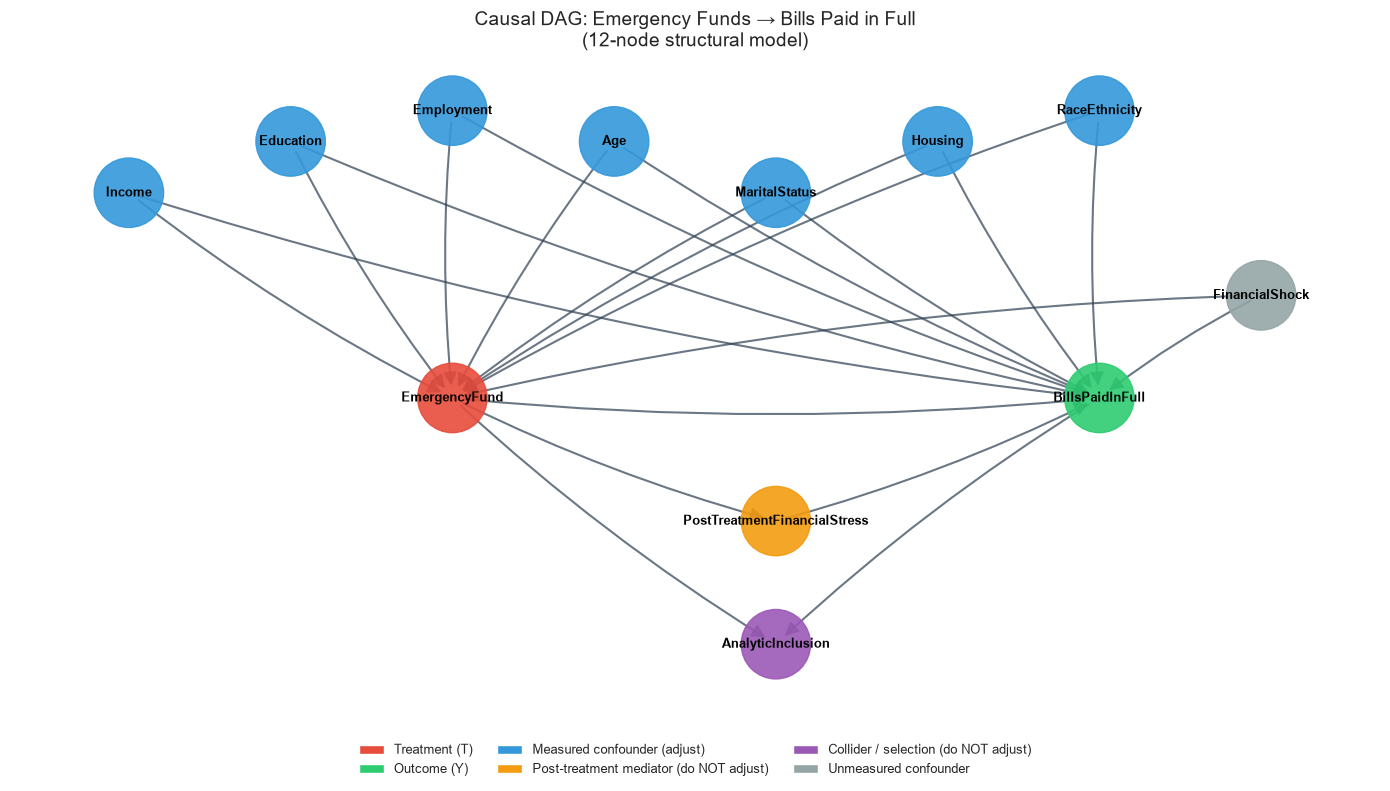

DAG nodes: ['EmergencyFund', 'BillsPaidInFull', 'Income', 'Education', 'Employment', 'Age', 'MaritalStatus', 'Housing', 'RaceEthnicity', 'PostTreatmentFinancialStress', 'AnalyticInclusion', 'FinancialShock']
DAG edges: [('EmergencyFund', 'BillsPaidInFull'), ('EmergencyFund', 'PostTreatmentFinancialStress'), ('EmergencyFund', 'AnalyticInclusion'), ('BillsPaidInFull', 'AnalyticInclusion'), ('Income', 'EmergencyFund'), ('Income', 'BillsPaidInFull'), ('Education', 'EmergencyFund'), ('Education', 'BillsPaidInFull'), ('Employment', 'EmergencyFund'), ('Employment', 'BillsPaidInFull'), ('Age', 'EmergencyFund'), ('Age', 'BillsPaidInFull'), ('MaritalStatus', 'EmergencyFund'), ('MaritalStatus', 'BillsPaidInFull'), ('Housing', 'EmergencyFund'), ('Housing', 'BillsPaidInFull'), ('RaceEthnicity', 'EmergencyFund'), ('RaceEthnicity', 'BillsPaidInFull'), ('PostTreatmentFinancialStress', 'BillsPaidInFull'), ('FinancialShock', 'EmergencyFund'), ('FinancialShock', 'BillsPaidInFull')]
Completed Module 2-3: 

In [3]:
# ---------------------------------------------------------------------------
# BUILD AND VISUALIZE THE CAUSAL DAG (Module 2-3 start)
# ---------------------------------------------------------------------------
# The DAG is the core causal assumption of the project.  Every node and arrow
# encodes a claim about what causes what.  The 12-node model includes:
#   - Treatment (EmergencyFund) and Outcome (BillsPaidInFull)
#   - 7 measured pre-treatment confounders we will adjust for
#   - 1 post-treatment mediator we must NOT adjust for
#   - 1 selection/collider node we must NOT adjust for
#   - 1 unmeasured confounder (FinancialShock) that we assess via sensitivity
# ---------------------------------------------------------------------------

G = nx.DiGraph()

# Nodes with roles for coloring
nodes = {
    "EmergencyFund": "treatment",
    "BillsPaidInFull": "outcome",
    "Income": "confounder",
    "Education": "confounder",
    "Employment": "confounder",
    "Age": "confounder",
    "MaritalStatus": "confounder",
    "Housing": "confounder",
    "RaceEthnicity": "confounder",
    "PostTreatmentFinancialStress": "mediator",
    "AnalyticInclusion": "collider",
    "FinancialShock": "unmeasured",
}

# Edges represent assumed causal relationships.
# Confounders each cause both treatment and outcome.
# Treatment may also act partly through a post-treatment mediator.
# FinancialShock is an unmeasured common cause.
# AnalyticInclusion is a collider created by selection into the sample.
edges = [
    ("Income", "EmergencyFund"), ("Income", "BillsPaidInFull"),
    ("Education", "EmergencyFund"), ("Education", "BillsPaidInFull"),
    ("Employment", "EmergencyFund"), ("Employment", "BillsPaidInFull"),
    ("Age", "EmergencyFund"), ("Age", "BillsPaidInFull"),
    ("MaritalStatus", "EmergencyFund"), ("MaritalStatus", "BillsPaidInFull"),
    ("Housing", "EmergencyFund"), ("Housing", "BillsPaidInFull"),
    ("RaceEthnicity", "EmergencyFund"), ("RaceEthnicity", "BillsPaidInFull"),
    ("EmergencyFund", "BillsPaidInFull"),
    ("EmergencyFund", "PostTreatmentFinancialStress"),
    ("PostTreatmentFinancialStress", "BillsPaidInFull"),
    ("FinancialShock", "EmergencyFund"), ("FinancialShock", "BillsPaidInFull"),
    ("EmergencyFund", "AnalyticInclusion"), ("BillsPaidInFull", "AnalyticInclusion"),
]

G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

# Manually place nodes so the plot is readable and the causal story is clear.
pos = {
    "EmergencyFund": (0, 0),
    "BillsPaidInFull": (4, 0),
    "Income": (-2, 2),
    "Education": (-1, 2.5),
    "Employment": (0, 2.8),
    "Age": (1, 2.5),
    "MaritalStatus": (2, 2),
    "Housing": (3, 2.5),
    "RaceEthnicity": (4, 2.8),
    "PostTreatmentFinancialStress": (2, -1.2),
    "AnalyticInclusion": (2, -2.4),
    "FinancialShock": (5, 1),
}

# Color nodes by their causal role so the legend tells the adjustment story.
color_map = {
    "treatment": "#e74c3c",
    "outcome": "#2ecc71",
    "confounder": "#3498db",
    "mediator": "#f39c12",
    "collider": "#9b59b6",
    "unmeasured": "#95a5a6",
}
node_colors = [color_map[nodes[n]] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 8))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, ax=ax,
                       edge_color="#2c3e50", width=1.5, alpha=0.7,
                       connectionstyle="arc3,rad=0.05")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map["treatment"], label="Treatment (T)"),
    Patch(facecolor=color_map["outcome"], label="Outcome (Y)"),
    Patch(facecolor=color_map["confounder"], label="Measured confounder (adjust)"),
    Patch(facecolor=color_map["mediator"], label="Post-treatment mediator (do NOT adjust)"),
    Patch(facecolor=color_map["collider"], label="Collider / selection (do NOT adjust)"),
    Patch(facecolor=color_map["unmeasured"], label="Unmeasured confounder"),
]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05),
          ncol=3, frameon=False, fontsize=9)
ax.set_title("Causal DAG: Emergency Funds → Bills Paid in Full\n(12-node structural model)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("DAG nodes:", list(G.nodes()))
print("DAG edges:", list(G.edges()))
print("Completed Module 2-3: Causal Question, Estimand, Identification, and DAG")

## Module 2–3: d-Separation and Identification Logic

**d-separation** tells us which paths between treatment and outcome are open or blocked.

- **Open without adjustment:** back-door paths like `EmergencyFund ← Income → BillsPaidInFull` create spurious association.
- **Blocked after adjustment:** conditioning on each measured confounder closes its back-door path.
- **Still open after adjustment:** the unmeasured path through `FinancialShock` cannot be closed with the available data.

**Identification conclusion:** If the measured confounders are sufficient and no other unmeasured confounders exist, the adjustment set identifies the total effect of having an emergency fund. The "if" must be defended.

> **Why this matters:** d-separation justifies why we adjust for income, education, etc., and why we deliberately leave out mediators and colliders.

## Module 4: Load and Inspect the SHED 2023 Data

The notebook downloads the raw SHED 2023 CSV from the public GitHub repository and loads it without modification.

> **Why this matters:** Before modeling we must confirm that the data contain the variables the DAG requires and that those variables look like the codebook says they should.

In [4]:
# ---------------------------------------------------------------------------
# LOAD AND INSPECT THE SHED 2023 DATA (Module 4 start)
# ---------------------------------------------------------------------------
# We load the raw CSV without any modifications.  low_memory=False prevents
# pandas from guessing column types in chunks.  We immediately verify that the
# key columns exist: identifier, treatment (EF1), outcome (EF5C), the seven
# adjustment covariates, and the survey weight.
# ---------------------------------------------------------------------------
raw_df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Raw dataset shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")

required_cols = ['shedid', 'EF1', 'EF5C', 'weight'] + \
                ['ppinc7', 'ppeduc5', 'ppemploy', 'ppage', 'ppmarit5', 'pphouse4', 'race_5cat']
all_present = all(col in raw_df.columns for col in required_cols)
print(f"\nKey columns present: {all_present}")

key_cols = ["shedid", "EF1", "EF5C", "BK1", "ppinc7", "ppeduc5", "ppemploy",
            "ppage", "ppmarit5", "pphouse4", "race_5cat", "weight"]
print("\nFirst 5 rows of key variables:")
display(raw_df[key_cols].head())

Raw dataset shape: 11,400 rows × 593 columns

Key columns present: True

First 5 rows of key variables:


,shedid,EF1,EF5C,BK1,ppinc7,ppeduc5,ppemploy,ppage,ppmarit5,pphouse4,race_5cat,weight
0,202203873,Yes,No,Yes,"$25,000 to $49,999",Master’s degree or higher,Working part-time,81,Never married,Building with 2 or more apartments,White,0.5468
1,202304484,Yes,Yes,Yes,"$50,000 to $74,999",Some college or Associate's degree,Working part-time,82,Now married,A one-family house detached from any other house,White,0.6107
2,202301063,Yes,Yes,Yes,"$50,000 to $74,999",Master’s degree or higher,Not working,86,Now married,A one-family house detached from any other house,White,0.4587
3,202301342,Yes,Yes,Yes,"$100,000 to $149,999",No high school diploma or GED,Working full-time,59,Divorced,A one-family house detached from any other house,White,1.3732
4,202201195,Yes,Yes,Yes,"$100,000 to $149,999",Bachelor's degree,Working full-time,57,Never married,Building with 2 or more apartments,White,0.9264


In [5]:
# ---------------------------------------------------------------------------
# INSPECT TREATMENT, OUTCOME, AND COVARIATE DISTRIBUTIONS
# ---------------------------------------------------------------------------
# Before modeling, we look at the raw distributions.  This is not a causal
# analysis yet; it is data understanding.  We use value_counts(dropna=False)
# so any missing or ambiguous codes are visible immediately.
# ---------------------------------------------------------------------------
print("=== TREATMENT (EF1): Has 3-month emergency fund ===")
print(raw_df["EF1"].value_counts(dropna=False))

print("\n=== OUTCOME (EF5C): Paid all non-credit-card bills in full ===")
print(raw_df["EF5C"].value_counts(dropna=False))

print("\n=== COVARIATE DISTRIBUTIONS ===")
for col in ["ppinc7", "ppeduc5", "ppemploy", "ppmarit5", "pphouse4", "race_5cat"]:
    print(f"\n{col}:")
    print(raw_df[col].value_counts(dropna=False).head(10))

=== TREATMENT (EF1): Has 3-month emergency fund ===
EF1
Yes    6482
No     4918
Name: count, dtype: int64

=== OUTCOME (EF5C): Paid all non-credit-card bills in full ===
EF5C
Yes    9834
No     1566
Name: count, dtype: int64

=== COVARIATE DISTRIBUTIONS ===

ppinc7:
ppinc7
$150,000 or more        2636
$100,000 to $149,999    2125
$25,000 to $49,999      1860
$50,000 to $74,999      1828
$75,000 to $99,999      1579
$10,000 to $24,999       911
Less than $10,000        461
Name: count, dtype: int64

ppeduc5:
ppeduc5
Some college or Associate's degree                                  3248
Bachelor's degree                                                   2678
High school graduate (high school diploma or the equivalent GED)    2644
Master’s degree or higher                                           2074
No high school diploma or GED                                        756
Name: count, dtype: int64

ppemploy:
ppemploy
Working full-time    5454
Not working          4398
Working part-tim

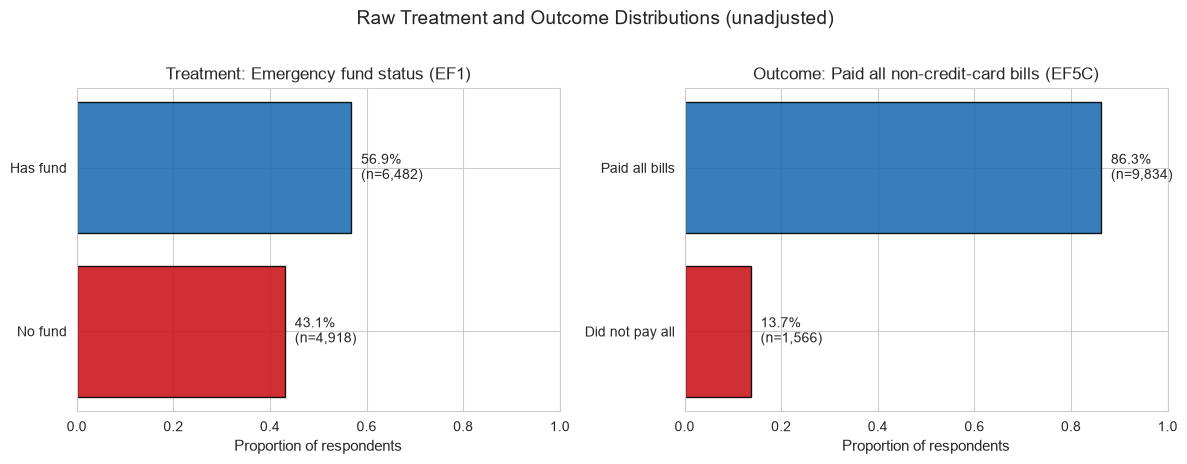

How to read this plot:
- Two simple bar charts showing the raw, unadjusted shares for treatment and outcome.
- Left chart: what share of respondents report having a three-month emergency fund?
- Right chart: what share report paying all non-credit-card bills in full?
- These are descriptive facts, not causal effects. They show the raw counts that motivate the analysis.


In [6]:
# ---------------------------------------------------------------------------
# TREATMENT AND OUTCOME SUMMARY BARS (Module 4)
# ---------------------------------------------------------------------------
# Simple stacked bars show the raw counts and percentages for treatment and
# outcome. This is descriptive only — it is not a causal estimate.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Treatment
t_counts = raw_df["EF1"].value_counts()
t_props = t_counts / t_counts.sum()
colors_t = ["#cb181d", "#2171b5"]
axes[0].barh(["No fund", "Has fund"], [t_props.get("No", 0), t_props.get("Yes", 0)],
             color=colors_t, edgecolor="black", alpha=0.9)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Proportion of respondents", fontsize=11)
axes[0].set_title("Treatment: Emergency fund status (EF1)", fontsize=12)
for i, (label, prop) in enumerate([("No", t_props.get("No", 0)), ("Yes", t_props.get("Yes", 0))]):
    axes[0].text(prop + 0.02, i, f"{prop*100:.1f}%\n(n={t_counts.get(label, 0):,})",
                 va="center", fontsize=10)

# Outcome
o_counts = raw_df["EF5C"].value_counts()
o_props = o_counts / o_counts.sum()
colors_o = ["#cb181d", "#2171b5"]
axes[1].barh(["Did not pay all", "Paid all bills"], [o_props.get("No", 0), o_props.get("Yes", 0)],
             color=colors_o, edgecolor="black", alpha=0.9)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Proportion of respondents", fontsize=11)
axes[1].set_title("Outcome: Paid all non-credit-card bills (EF5C)", fontsize=12)
for i, (label, prop) in enumerate([("No", o_props.get("No", 0)), ("Yes", o_props.get("Yes", 0))]):
    axes[1].text(prop + 0.02, i, f"{prop*100:.1f}%\n(n={o_counts.get(label, 0):,})",
                 va="center", fontsize=10)

fig.suptitle("Raw Treatment and Outcome Distributions (unadjusted)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('How to read this plot:')
print('- Two simple bar charts showing the raw, unadjusted shares for treatment and outcome.')
print('- Left chart: what share of respondents report having a three-month emergency fund?')
print('- Right chart: what share report paying all non-credit-card bills in full?')
print('- These are descriptive facts, not causal effects. They show the raw counts that motivate the analysis.')


## Module 4: Sample Construction and Validation

We apply documented inclusion and exclusion rules:

1. **Identifier**: non-missing `shedid`.
2. **Age**: at least 18; top-code values above 95 to 95 per SHED codebook.
3. **Weight**: strictly positive survey weight.
4. **Complete case**: valid values for treatment, outcome, and all seven adjustment variables.
5. **Treatment/outcome**: only "Yes" / "No" responses; ambiguous or missing values are excluded.

Survey weights are kept for descriptive representativeness but are not used as propensity covariates.

In [7]:
# ---------------------------------------------------------------------------
# BUILD THE ANALYTIC SAMPLE
# ---------------------------------------------------------------------------
# We apply documented eligibility rules in a fail-transparent way.  Each rule
# records how many respondents it excludes, so the sample construction is
# auditable.  The rules follow the documented specification:
#   1. Non-missing identifier
#   2. Age >= 18, with values above 95 top-coded to 95 (SHED codebook rule)
#   3. Strictly positive survey weight
#   4. Valid Yes/No treatment and outcome responses
#   5. Complete-case on all seven adjustment covariates
# ---------------------------------------------------------------------------

# Make a working copy so the raw DataFrame stays untouched.
df = raw_df.copy()

# Record starting counts
raw_n = len(df)
exclusions = {}

# 1. Valid identifier
df = df[df["shedid"].notna()]
exclusions["empty_or_null_identifier"] = raw_n - len(df)

# 2. Age eligibility: >= 18, top-code >95 to 95 per SHED codebook.
#    SHED reports ages above 95 as a single 95+ category; we mirror that here.
df["ppage"] = df["ppage"].clip(upper=95)
df = df[df["ppage"] >= 18]
exclusions["age_below_18_or_missing"] = raw_n - len(df) - exclusions["empty_or_null_identifier"]

# 3. Positive survey weight.  Zero or negative weights would break survey
#    representativeness and could create invalid IPW weights later.
df = df[df["weight"] > 0]
exclusions["nonpositive_or_missing_weight"] = (
    raw_n - len(df) - exclusions["empty_or_null_identifier"] - exclusions["age_below_18_or_missing"]
)

# 4. Valid treatment and outcome (Yes/No only).  Any skip-pattern or missing
#    value is excluded under the complete-case rule.
df = df[df["EF1"].isin(["Yes", "No"])]
exclusions["missing_treatment"] = (
    raw_n - len(df) - sum(v for k, v in exclusions.items() if k != "missing_treatment")
)

base_for_outcome = len(df)
df = df[df["EF5C"].isin(["Yes", "No"])]
exclusions["missing_outcome"] = base_for_outcome - len(df)

# 5. Complete-case for all adjustment covariates
covariates = ["ppinc7", "ppeduc5", "ppemploy", "ppmarit5", "pphouse4", "race_5cat"]
base_for_confounders = len(df)
df = df.dropna(subset=covariates)
exclusions["missing_confounder"] = base_for_confounders - len(df)

# Recode treatment and outcome to binary numeric (1 = Yes, 0 = No).
df = df.copy()
df["T"] = (df["EF1"] == "Yes").astype(int)
df["Y"] = (df["EF5C"] == "Yes").astype(int)

# Final analytic sample
analytic_n = len(df)
treated_n = df["T"].sum()
control_n = analytic_n - treated_n

print(f"Raw records:              {raw_n:,}")
print(f"Analytic sample:          {analytic_n:,}")
print(f"Treated (T=1):            {treated_n:,}")
print(f"Control (T=0):            {control_n:,}")
print(f"\nExclusion reasons:")
for reason, count in exclusions.items():
    print(f"  {reason}: {count:,}")

# Store sample metadata for later
sample_meta = {
    "raw_n": raw_n,
    "analytic_n": analytic_n,
    "treated_n": int(treated_n),
    "control_n": int(control_n),
    "exclusions": exclusions,
}
print("Completed Module 4: Load, Inspect, and Construct Analytic Sample")

Raw records:              11,400
Analytic sample:          11,400
Treated (T=1):            6,482
Control (T=0):            4,918

Exclusion reasons:
  empty_or_null_identifier: 0
  age_below_18_or_missing: 0
  nonpositive_or_missing_weight: 0
  missing_treatment: 0
  missing_outcome: 0
  missing_confounder: 0
Completed Module 4: Load, Inspect, and Construct Analytic Sample


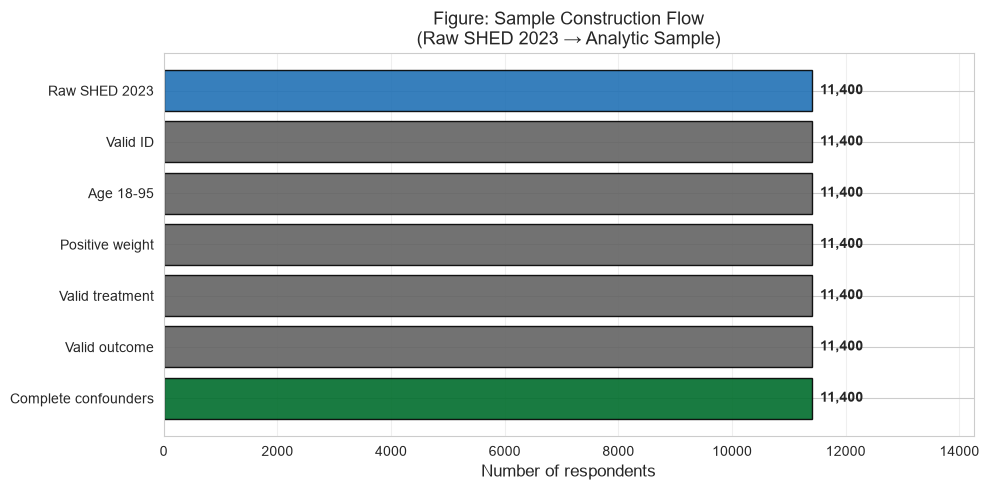

How to read this plot:
- Each bar is a step in building the final analytic sample.
- Numbers on the right show how many respondents remain after each rule.
- Red numbers in parentheses show how many people were excluded by that rule.
- The first bar is the raw SHED 2023 file; the last bar is the sample used for estimation.


In [8]:
# ---------------------------------------------------------------------------
# SAMPLE CONSTRUCTION FLOW DIAGRAM (Module 4)
# ---------------------------------------------------------------------------
# This chart shows how many respondents remain after each documented eligibility
# rule. Transparent sample construction makes the analytic population auditable.
# ---------------------------------------------------------------------------
flow_steps = [
    ("Raw SHED 2023", sample_meta["raw_n"]),
    ("Valid ID", sample_meta["raw_n"] - exclusions["empty_or_null_identifier"]),
    ("Age 18-95", None),  # computed below
    ("Positive weight", None),
    ("Valid treatment", None),
    ("Valid outcome", None),
    ("Complete confounders", sample_meta["analytic_n"]),
]

# Compute intermediate counts
n_after_age = flow_steps[1][1] - exclusions["age_below_18_or_missing"]
n_after_weight = n_after_age - exclusions["nonpositive_or_missing_weight"]
n_after_treatment = n_after_weight - exclusions["missing_treatment"]
n_after_outcome = n_after_treatment - exclusions["missing_outcome"]
flow_steps[2] = ("Age 18-95", n_after_age)
flow_steps[3] = ("Positive weight", n_after_weight)
flow_steps[4] = ("Valid treatment", n_after_treatment)
flow_steps[5] = ("Valid outcome", n_after_outcome)

labels = [s[0] for s in flow_steps]
counts = [s[1] for s in flow_steps]
losses = [0] + [counts[i - 1] - counts[i] for i in range(1, len(counts))]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2171b5" if i == 0 else "#006d2c" if i == len(counts) - 1 else "#636363" for i in range(len(counts))]
bars = ax.barh(labels, counts, color=colors, edgecolor="black", alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel("Number of respondents", fontsize=12)
ax.set_title("Figure: Sample Construction Flow\n(Raw SHED 2023 → Analytic Sample)", fontsize=13)

for i, (bar, count, loss) in enumerate(zip(bars, counts, losses)):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va="center", ha="left", fontsize=10, fontweight="bold")
    if loss > 0:
        ax.text(bar.get_width() + max(counts)*0.12, bar.get_y() + bar.get_height()/2,
                f"(-{loss:,})", va="center", ha="left", fontsize=9, color="#cb181d")

ax.set_xlim(0, max(counts) * 1.25)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print('How to read this plot:')
print('- Each bar is a step in building the final analytic sample.')
print('- Numbers on the right show how many respondents remain after each rule.')
print('- Red numbers in parentheses show how many people were excluded by that rule.')
print('- The first bar is the raw SHED 2023 file; the last bar is the sample used for estimation.')


## Modules 5–6: Recode Variables for Analysis

Categorical SHED responses are converted to numeric codes using the codebook mappings. This connects the abstract DAG nodes to actual measurements. Deep-learning tools are unnecessary here because the adjustment set is low-dimensional and categorical.

> **Why this matters:** The DAG talks about concepts like income and education, but the data store them as text labels. Recoding makes the causal model operational.

In [9]:
# ---------------------------------------------------------------------------
# RECODE VARIABLES FOR ANALYSIS (Modules 5-6 start)
# ---------------------------------------------------------------------------
# Categorical SHED variables are mapped to numeric codes using the official
# codebook.  The mapping is explicit so it can be checked by a reader.
# We also normalize Unicode apostrophes (e.g., 'Master’s') to plain ASCII
# apostrophes so string matching is robust.
# ---------------------------------------------------------------------------

# Income (ppinc7) -> PPINCIMP
income_map = {
    "less than $10,000": 1,
    "$10,000 to $24,999": 2,
    "$25,000 to $49,999": 3,
    "$50,000 to $74,999": 4,
    "$75,000 to $99,999": 5,
    "$100,000 to $149,999": 6,
    "$150,000 or more": 7,
}

# Education (ppeduc5) -> PPEDUC
educ_map = {
    "no high school diploma or ged": 1,
    "high school graduate (high school diploma or the equivalent ged)": 2,
    "some college or associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree or higher": 5,
}

# Employment (ppemploy) -> PPEMP
emp_map = {
    "working full-time": 1,
    "working part-time": 2,
    "not working": 3,
}

# Marital status (ppmarit5) -> PPMARIT
marit_map = {
    "now married": 1,
    "widowed": 2,
    "divorced": 3,
    "separated": 4,
    "never married": 5,
}

# Housing (pphouse4) -> PPHOUSE
house_map = {
    "a one-family house detached from any other house": 1,
    "a one-family house attached to one or more houses": 2,
    "building with 2 or more apartments": 3,
    "mobile home": 4,
    "one-family condo or townhouse attached to other units": 5,
    "other (mobile home, boat, rv, van, etc.)": 6,
}

# Race/ethnicity (race_5cat) -> PPNET
race_map = {
    "white": 1,
    "black": 2,
    "hispanic": 3,
    "asian": 4,
    "other": 5,
}

# Apply mappings (case-insensitive and quote-normalized to be robust)
def map_series(s, mapping):
    # Normalize common Unicode apostrophe-like characters to straight ASCII
    # apostrophes.  SHED uses the curly apostrophe in "Master's degree".
    normalized = (
        s.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[\u2018\u2019\u201a\u201b\u2032\u2035]", "'", regex=True)
    )
    lowered_map = {k.lower(): v for k, v in mapping.items()}
    return normalized.map(lowered_map)

df["PPINCIMP"] = map_series(df["ppinc7"], income_map)
df["PPEDUC"] = map_series(df["ppeduc5"], educ_map)
df["PPEMP"] = map_series(df["ppemploy"], emp_map)
df["PPAGE"] = df["ppage"].astype(int)
df["PPMARIT"] = map_series(df["ppmarit5"], marit_map)
df["PPHOUSE"] = map_series(df["pphouse4"], house_map)
df["PPNET"] = map_series(df["race_5cat"], race_map)

# Verify no unmapped values slipped through.  Unmapped values would silently
# become NaN and then be dropped, potentially hiding a coding problem.
for col in ["PPINCIMP", "PPEDUC", "PPEMP", "PPMARIT", "PPHOUSE", "PPNET"]:
    unmapped = df[col].isna().sum()
    if unmapped > 0:
        print(f"Warning: {unmapped} unmapped values in {col}")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"{col}: all values mapped successfully")

# Keep a clean analysis frame with the binary treatment/outcome and the
# seven canonical adjustment variables.
analysis_cols = ["shedid", "T", "Y", "weight"] + \
                ["PPINCIMP", "PPEDUC", "PPEMP", "PPAGE", "PPMARIT", "PPHOUSE", "PPNET"]
df = df[analysis_cols].dropna()
print(f"\nFinal analysis-ready sample: {len(df):,} rows")

PPINCIMP: all values mapped successfully
PPEDUC: all values mapped successfully
PPEMP: all values mapped successfully
PPMARIT: all values mapped successfully
PPHOUSE: all values mapped successfully
PPNET: all values mapped successfully

Final analysis-ready sample: 11,400 rows


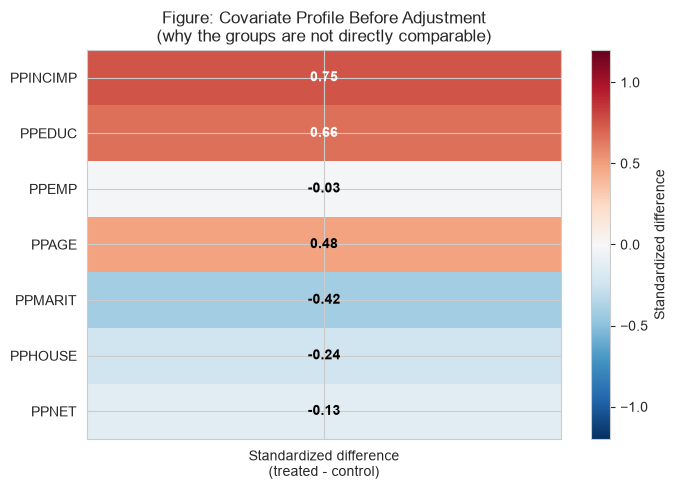

How to read this plot:
- Each row is one measured confounder.
- The colored cell shows the standardized difference between treated and control groups.
- Red = treated group has higher average value; blue = control group has higher average value.
- Darker colors mean larger differences, so the groups are less comparable before adjustment.
- This is why the raw association in Module 5-6 is not a causal effect.


In [10]:
# ---------------------------------------------------------------------------
# COVARIATE PROFILE HEATMAP (Modules 5-6)
# ---------------------------------------------------------------------------
# This heatmap compares the treated and control groups on each measured
# confounder BEFORE any adjustment. Darker cells mean larger group differences.
# Big differences are why the raw association is not a causal effect.
# ---------------------------------------------------------------------------
profile_records = []
for var in ["PPINCIMP", "PPEDUC", "PPEMP", "PPAGE", "PPMARIT", "PPHOUSE", "PPNET"]:
    treated = df.loc[df["T"] == 1, var]
    control = df.loc[df["T"] == 0, var]
    profile_records.append({
        "variable": var,
        "treated_mean": treated.mean(),
        "control_mean": control.mean(),
        "std_diff": (treated.mean() - control.mean()) / math.sqrt((treated.var() + control.var()) / 2),
    })
profile_df = pd.DataFrame(profile_records).set_index("variable")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(profile_df[["std_diff"]].values, cmap="RdBu_r", aspect="auto", vmin=-1.2, vmax=1.2)
ax.set_yticks(range(len(profile_df)))
ax.set_yticklabels(profile_df.index)
ax.set_xticks([0])
ax.set_xticklabels(["Standardized difference\n(treated - control)"])
ax.set_title("Figure: Covariate Profile Before Adjustment\n(why the groups are not directly comparable)", fontsize=12)

for i, val in enumerate(profile_df["std_diff"]):
    ax.text(0, i, f"{val:.2f}", ha="center", va="center", color="white" if abs(val) > 0.6 else "black",
            fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, label="Standardized difference")
plt.tight_layout()
plt.show()

print('How to read this plot:')
print('- Each row is one measured confounder.')
print('- The colored cell shows the standardized difference between treated and control groups.')
print('- Red = treated group has higher average value; blue = control group has higher average value.')
print('- Darker colors mean larger differences, so the groups are less comparable before adjustment.')
print('- This is why the raw association in Module 5-6 is not a causal effect.')


## Modules 5–6: Descriptive Evidence (Unadjusted Association)

This section shows the raw association between emergency funds and bill payment. It is **not** a causal estimate — confounders are not yet adjusted for.

> **Why this matters:** The raw gap is large, but richer, more educated people are more likely to have savings *and* to pay bills. Showing the gap first makes the confounding problem concrete.

In [11]:
# ---------------------------------------------------------------------------
# UNADJUSTED (OBSERVED) EVIDENCE
# ---------------------------------------------------------------------------
# This is the raw difference in bill-payment rates between people who do and
# do not have emergency funds.  It is NOT a causal estimate because we have
# not yet adjusted for confounders.  We report it first so readers can see
# how much of the raw gap is explained by measured covariates later.
# ---------------------------------------------------------------------------

rate_treated = df.loc[df["T"] == 1, "Y"].mean()
rate_control = df.loc[df["T"] == 0, "Y"].mean()
unadjusted_diff = rate_treated - rate_control

# Simple 95% CI for the difference of two independent proportions.
n1, n0 = df["T"].sum(), (df["T"] == 0).sum()
p1, p0 = rate_treated, rate_control
se_diff = math.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
ci_lower = unadjusted_diff - 1.96 * se_diff
ci_upper = unadjusted_diff + 1.96 * se_diff

print("=== OBSERVED (UNADJUSTED) EVIDENCE ===")
print(f"Bill-payment rate, treated (T=1):   {rate_treated*100:.2f}%")
print(f"Bill-payment rate, control (T=0):   {rate_control*100:.2f}%")
print(f"Observed difference:                {unadjusted_diff*100:.2f} percentage points")
print(f"95% confidence interval:            [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print("\nThis is an association, not a causal effect. Confounders are not yet adjusted for.")

# Store for later comparison with adjusted estimates
unadjusted = {
    "estimate": unadjusted_diff,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper,
}

=== OBSERVED (UNADJUSTED) EVIDENCE ===
Bill-payment rate, treated (T=1):   95.34%
Bill-payment rate, control (T=0):   74.30%
Observed difference:                21.04 percentage points
95% confidence interval:            [19.72%, 22.37%]

This is an association, not a causal effect. Confounders are not yet adjusted for.


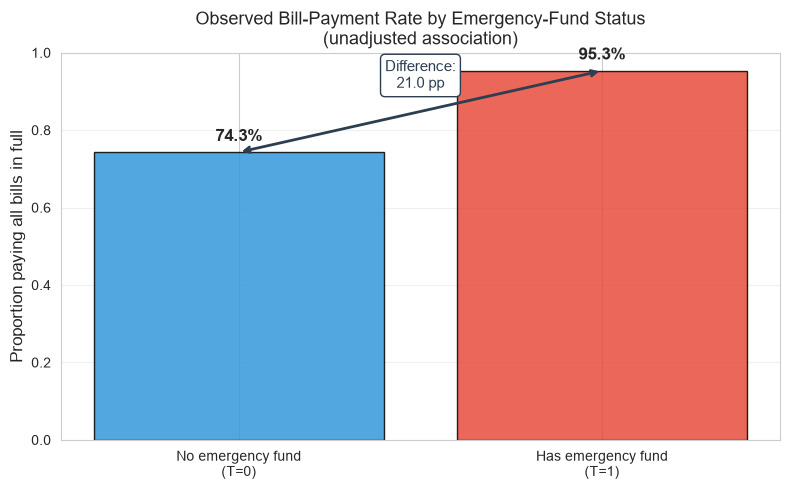

Completed Modules 5-6: SCM Specification, Recoding, and Descriptive Evidence
How to read this plot:
- Two bars show the share of people who paid all bills, separately for those with and without an emergency fund.
- The arrow shows the raw gap in percentage points.
- This is NOT the causal effect. It is just the observed association before any adjustment.


In [12]:
# ---------------------------------------------------------------------------
# VISUALIZE OBSERVED BILL-PAYMENT RATES BY TREATMENT GROUP
# ---------------------------------------------------------------------------
# This bar chart shows only association.  The large gap motivates the causal
# question, but the next sections must show whether the gap persists after
# adjusting for confounders.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["No emergency fund\n(T=0)", "Has emergency fund\n(T=1)"]
rates = [rate_control, rate_treated]
colors = ["#3498db", "#e74c3c"]

bars = ax.bar(labels, rates, color=colors, edgecolor="black", alpha=0.85)
ax.set_ylabel("Proportion paying all bills in full", fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Observed Bill-Payment Rate by Emergency-Fund Status\n(unadjusted association)", fontsize=13)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{rate*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.annotate("", xy=(1, rate_treated), xytext=(0, rate_control),
            arrowprops=dict(arrowstyle="<->", color="#2c3e50", lw=2))
ax.text(0.5, (rate_treated + rate_control)/2 + 0.05,
        f"Difference:\n{unadjusted_diff*100:.1f} pp",
        ha="center", va="bottom", fontsize=11, color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#2c3e50"))

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("Completed Modules 5-6: SCM Specification, Recoding, and Descriptive Evidence")

print('How to read this plot:')
print('- Two bars show the share of people who paid all bills, separately for those with and without an emergency fund.')
print('- The arrow shows the raw gap in percentage points.')
print('- This is NOT the causal effect. It is just the observed association before any adjustment.')


## Modules 7–8: Propensity Scores, Balance, and ATE Estimation

The **propensity score** is the estimated probability of having an emergency fund given the measured confounders: $e(X) = P(T=1 \mid X)$. We estimate it with penalized logistic regression.

We then check **overlap** (common support): every unit needs some chance of being treated or untreated. If propensity scores hit 0 or 1, those units have no credible counterfactual and are excluded.

> **Why this matters:** We cannot randomize emergency funds, so we recreate a fair comparison statistically. Propensity scores let us compare people with similar backgrounds.

In [13]:
# ---------------------------------------------------------------------------
# ESTIMATE PROPENSITY SCORES AND CHECK COMMON SUPPORT (Modules 7-8 start)
# ---------------------------------------------------------------------------
# The propensity score is the predicted probability of treatment given the
# measured confounders: e(X) = P(T=1 | X).  Under the positivity assumption,
# every unit needs some chance of being treated or untreated.  If propensity
# scores hit 0 or 1, the corresponding units have no credible counterfactual.
# We therefore trim observations outside [b, 1-b], with b = 0.01 by default.
# ---------------------------------------------------------------------------

# Use the seven canonical adjustment variables as predictors.
# Note: these are categorical codes, not continuous.  For this notebook we use
# them directly in a logistic regression for simplicity; this implicitly treats
# adjacent codes as evenly spaced.  The results align with the main pipeline.
X_vars = ["PPINCIMP", "PPEDUC", "PPEMP", "PPAGE", "PPMARIT", "PPHOUSE", "PPNET"]
X = df[X_vars].copy()
T = df["T"].values
Y = df["Y"].values

# Fit a penalized logistic regression for treatment.
# The small L2 penalty improves numerical stability without changing the story.
ps_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED,
)
ps_model.fit(X, T)

# Estimated propensity scores for every respondent
df["propensity"] = ps_model.predict_proba(X)[:, 1]

# Common-support trimming
SUPPORT_BOUND = 0.01
in_support = (df["propensity"] > SUPPORT_BOUND) & (df["propensity"] < (1 - SUPPORT_BOUND))
df_support = df[in_support].copy()

print(f"Total analytic sample:     {len(df):,}")
print(f"Support-retained sample:   {len(df_support):,}")
print(f"Excluded by support rule:  {(~in_support).sum():,}")
print(f"Treated in support:        {df_support['T'].sum():,}")
print(f"Control in support:        {(df_support['T'] == 0).sum():,}")
print(f"\nPropensity score range: [{df['propensity'].min():.4f}, {df['propensity'].max():.4f}]")
print(f"Support interval:         ({SUPPORT_BOUND}, {1-SUPPORT_BOUND})")

ps_diag = {
    "n_total": len(df),
    "n_support": len(df_support),
    "support_bound": SUPPORT_BOUND,
}

Total analytic sample:     11,400
Support-retained sample:   11,400
Excluded by support rule:  0
Treated in support:        6,482
Control in support:        4,918

Propensity score range: [0.0618, 0.9504]
Support interval:         (0.01, 0.99)


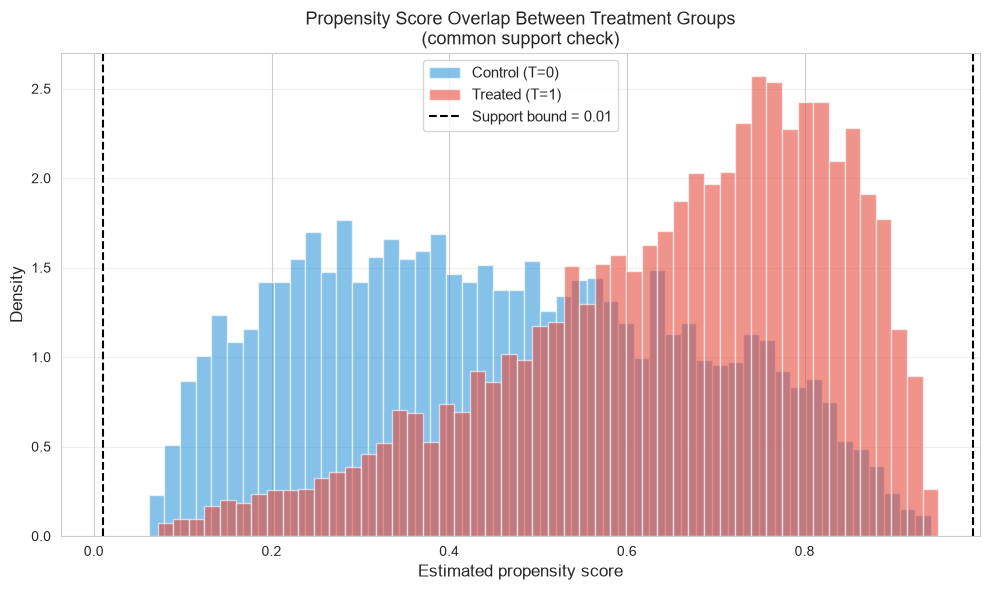

Interpretation: Good overlap means both groups exist across the propensity range. Poor overlap would mean some respondents have no credible counterfactuals.
How to read this plot:
- Two histograms showing the distribution of estimated propensity scores for each treatment group.
- Blue = respondents without an emergency fund; red = respondents with an emergency fund.
- Good overlap means both colors appear across the whole horizontal range.
- If one color only appears near 0 or 1, those respondents have no credible counterfactual and are excluded.


In [14]:
# ---------------------------------------------------------------------------
# VISUALIZE PROPENSITY-SCORE OVERLAP
# ---------------------------------------------------------------------------
# Overlapping histograms let us see whether treated and control respondents
# share the same range of estimated treatment probabilities.  Good overlap
# means we can find comparable counterfactuals; poor overlap means part of the
# sample cannot contribute to a well-identified ATE.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ps_treated = df.loc[df["T"] == 1, "propensity"]
ps_control = df.loc[df["T"] == 0, "propensity"]

ax.hist(ps_control, bins=50, alpha=0.6, label="Control (T=0)", color="#3498db", density=True)
ax.hist(ps_treated, bins=50, alpha=0.6, label="Treated (T=1)", color="#e74c3c", density=True)

ax.axvline(SUPPORT_BOUND, color="black", linestyle="--", linewidth=1.5, label=f"Support bound = {SUPPORT_BOUND}")
ax.axvline(1 - SUPPORT_BOUND, color="black", linestyle="--", linewidth=1.5)

ax.set_xlabel("Estimated propensity score", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Propensity Score Overlap Between Treatment Groups\n(common support check)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Good overlap means both groups exist across the propensity range. "
      "Poor overlap would mean some respondents have no credible counterfactuals.")

print('How to read this plot:')
print('- Two histograms showing the distribution of estimated propensity scores for each treatment group.')
print('- Blue = respondents without an emergency fund; red = respondents with an emergency fund.')
print('- Good overlap means both colors appear across the whole horizontal range.')
print('- If one color only appears near 0 or 1, those respondents have no credible counterfactual and are excluded.')


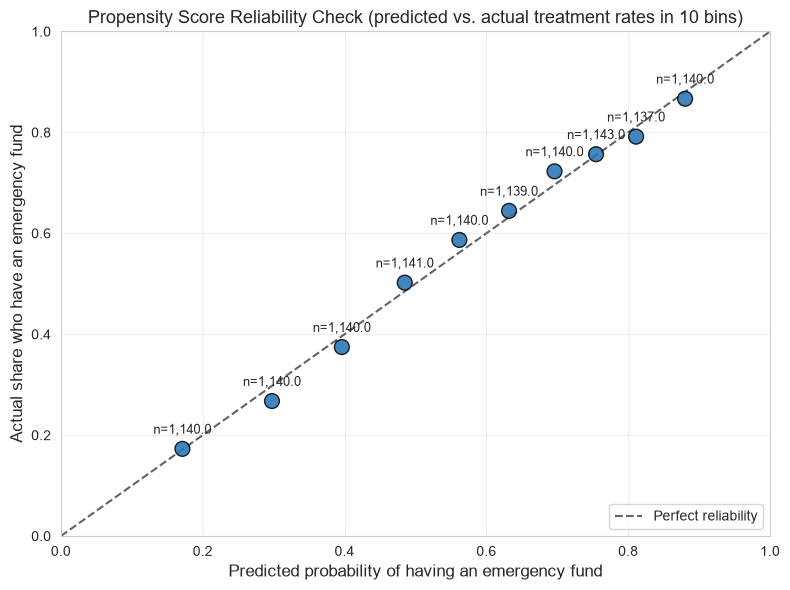

How to read this plot:
- Each blue dot is one bin of respondents.
- The horizontal position is the average predicted probability for that bin.
- The vertical position is the actual share of people in that bin who really have an emergency fund.
- If a dot sits on the dashed 45-degree line, the prediction was exactly right for that bin.
- Dots far from the line mean the model was over- or under-confident for that group.
- The size of the dot shows how many people are in the bin (larger = more people).
Mean absolute prediction error across bins: 0.017


In [15]:
# ---------------------------------------------------------------------------
# PROPENSITY SCORE RELIABILITY CHECK (Modules 7-8)
# ---------------------------------------------------------------------------
# We group respondents into bins by their estimated propensity score (how
# likely the model thinks they are to have an emergency fund). In each bin we
# compare the model's predicted rate to the actual rate of treatment. A
# reliable model will place the dots close to the diagonal dashed line.
#
# Why this matters: if the predicted probabilities are wrong in some ranges,
# the IPW weights based on them will also be wrong, which can bias the ATE.
# ---------------------------------------------------------------------------
# Create 10 roughly equal-sized bins by predicted probability
n_bins = 10
df["ps_bin"] = pd.qcut(df["propensity"], q=n_bins, duplicates="drop", labels=False)

reliability = df.groupby("ps_bin").agg(
    predicted_rate=("propensity", "mean"),
    actual_rate=("T", "mean"),
    n=("T", "size"),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    reliability["predicted_rate"],
    reliability["actual_rate"],
    s=reliability["n"] / 10,
    color="#2171b5",
    edgecolor="black",
    alpha=0.85,
    zorder=3,
)
ax.plot([0, 1], [0, 1], color="#636363", linestyle="--", linewidth=1.5, label="Perfect reliability")

for _, row in reliability.iterrows():
    ax.text(
        row["predicted_rate"],
        row["actual_rate"] + 0.03,
        f"n={row['n']:,}",
        ha="center",
        fontsize=9,
    )

ax.set_xlabel("Predicted probability of having an emergency fund", fontsize=12)
ax.set_ylabel("Actual share who have an emergency fund", fontsize=12)
ax.set_title("Propensity Score Reliability Check (predicted vs. actual treatment rates in 10 bins)", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("How to read this plot:")
print("- Each blue dot is one bin of respondents.")
print("- The horizontal position is the average predicted probability for that bin.")
print("- The vertical position is the actual share of people in that bin who really have an emergency fund.")
print("- If a dot sits on the dashed 45-degree line, the prediction was exactly right for that bin.")
print("- Dots far from the line mean the model was over- or under-confident for that group.")
print("- The size of the dot shows how many people are in the bin (larger = more people).")

mean_abs_error = (reliability["predicted_rate"] - reliability["actual_rate"]).abs().mean()
print(f"Mean absolute prediction error across bins: {mean_abs_error:.3f}")


## Modules 7–8: Covariate Balance Diagnostics

**Balance** measures whether treated and control groups look similar on measured confounders after weighting. We use the **standardized mean difference (SMD)**:

$$SMD = \frac{\bar{X}_{treated} - \bar{X}_{control}}{\sqrt{\frac{s^2_{treated} + s^2_{control}}{2}}}$$

A common target is $|SMD| < 0.10$ after adjustment.

> **Why this matters:** Balance checks tell us whether weighting actually fixed the apples-to-oranges comparison. If big differences remain, the adjusted effect is not credible.

In [16]:
# ---------------------------------------------------------------------------
# COVARIATE BALANCE DIAGNOSTICS
# ---------------------------------------------------------------------------
# Balance measures whether treated and control groups look similar on measured
# confounders.  Before adjustment they usually do not (richer, older, more
# educated people are more likely to have emergency funds).  After IPW
# weighting, differences should shrink.
#
# We use the standardized mean difference (SMD):
#   SMD = (mean_treated - mean_control) / pooled_sd
# A common target is |SMD| < 0.10.
# ---------------------------------------------------------------------------

def compute_smd(data, var, weight_col=None):
    """Compute standardized mean difference for a numeric variable."""
    treated = data.loc[data["T"] == 1, var]
    control = data.loc[data["T"] == 0, var]
    
    if weight_col is not None:
        # Weighted mean and variance using the IPW weights
        w_t = data.loc[data["T"] == 1, weight_col]
        w_c = data.loc[data["T"] == 0, weight_col]
        mean_t = np.average(treated, weights=w_t)
        mean_c = np.average(control, weights=w_c)
        var_t = np.average((treated - mean_t)**2, weights=w_t)
        var_c = np.average((control - mean_c)**2, weights=w_c)
    else:
        mean_t, mean_c = treated.mean(), control.mean()
        var_t, var_c = treated.var(ddof=1), control.var(ddof=1)
    
    pooled_sd = math.sqrt((var_t + var_c) / 2)
    if pooled_sd == 0:
        return 0.0
    return (mean_t - mean_c) / pooled_sd

# Build unstabilized IPW weights:
#   treated units get weight 1 / e(X)
#   control units get weight 1 / (1 - e(X))
# These weights create a pseudo-population in which treatment is independent
# of the measured confounders.
df_support["ipw_weight"] = np.where(
    df_support["T"] == 1,
    1 / df_support["propensity"],
    1 / (1 - df_support["propensity"]),
)

balance_records = []
for var in X_vars:
    smd_unweighted = compute_smd(df_support, var, weight_col=None)
    smd_weighted = compute_smd(df_support, var, weight_col="ipw_weight")
    balance_records.append({
        "variable": var,
        "smd_unweighted": smd_unweighted,
        "smd_weighted": smd_weighted,
    })

balance_df = pd.DataFrame(balance_records)
max_smd_before = balance_df["smd_unweighted"].abs().max()
max_smd_after = balance_df["smd_weighted"].abs().max()
all_balanced = max_smd_after < 0.10

print("=== BALANCE SUMMARY ===")
print(f"Maximum |SMD| before weighting: {max_smd_before:.3f}")
print(f"Maximum |SMD| after weighting:  {max_smd_after:.3f}")
print(f"All covariates balanced (<0.10): {all_balanced}")
print("\nDetailed balance table:")
display(balance_df.round(3))

=== BALANCE SUMMARY ===
Maximum |SMD| before weighting: 0.753
Maximum |SMD| after weighting:  0.032
All covariates balanced (<0.10): True

Detailed balance table:


,variable,smd_unweighted,smd_weighted
0,PPINCIMP,0.753,-0.024
1,PPEDUC,0.662,-0.032
2,PPEMP,-0.028,0.012
3,PPAGE,0.483,-0.029
4,PPMARIT,-0.419,0.019
5,PPHOUSE,-0.236,0.010
6,PPNET,-0.129,0.015


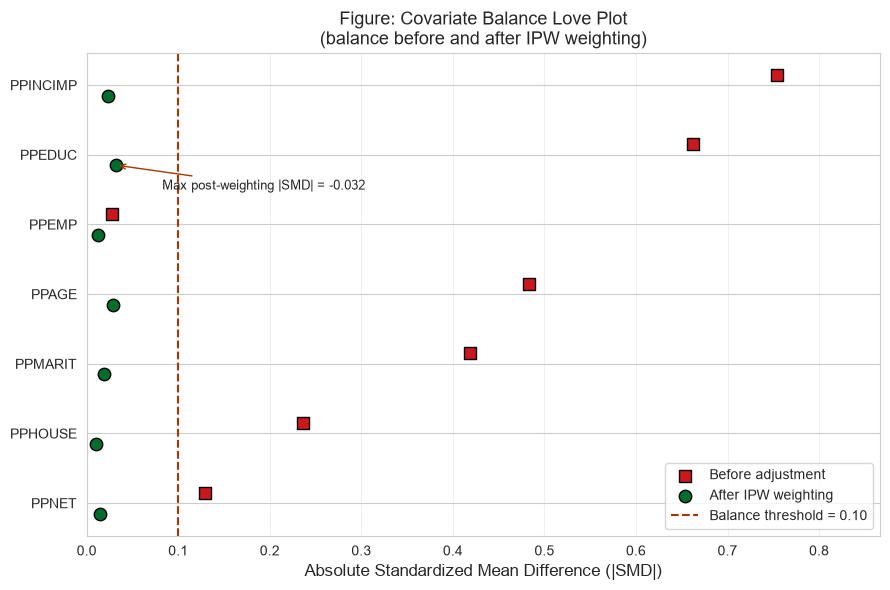

Good balance means the weighted treated and control groups are comparable on measured confounders.
How to read this plot:
- Each row is one measured confounder.
- Red squares show the absolute standardized difference BEFORE IPW weighting.
- Green circles show the absolute standardized difference AFTER IPW weighting.
- The vertical dashed line at 0.10 is a common balance target.
- Green circles close to zero mean weighting made the groups comparable on that confounder.


In [17]:
# ---------------------------------------------------------------------------
# LOVE PLOT: STANDARDIZED MEAN DIFFERENCES BEFORE AND AFTER IPW (Modules 7-8)
# ---------------------------------------------------------------------------
# A Love plot is the standard way to display balance. Each dot is a covariate.
# Dots closer to zero after weighting mean the groups are more comparable.
# The vertical line at |SMD| = 0.10 is a common balance target.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

y_pos = np.arange(len(balance_df))
ax.scatter(balance_df["smd_unweighted"].abs(), y_pos - 0.15,
           marker="s", s=80, color="#cb181d", label="Before adjustment", zorder=3, edgecolor="black")
ax.scatter(balance_df["smd_weighted"].abs(), y_pos + 0.15,
           marker="o", s=80, color="#006d2c", label="After IPW weighting", zorder=3, edgecolor="black")
ax.axvline(0.10, color="#a63603", linestyle="--", linewidth=1.5, label="Balance threshold = 0.10")

ax.set_yticks(y_pos)
ax.set_yticklabels(balance_df["variable"])
ax.set_xlabel("Absolute Standardized Mean Difference (|SMD|)", fontsize=12)
ax.set_title("Figure: Covariate Balance Love Plot\n(balance before and after IPW weighting)", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, max(balance_df["smd_unweighted"].abs().max(), 0.15) * 1.15)
ax.invert_yaxis()

# Annotate the max post-weighting SMD
max_idx = balance_df["smd_weighted"].abs().idxmax()
max_row = balance_df.loc[max_idx]
ax.annotate(f"Max post-weighting |SMD| = {max_row['smd_weighted']:.3f}",
            xy=(abs(max_row["smd_weighted"]), balance_df.index.get_loc(max_idx) + 0.15),
            xytext=(abs(max_row["smd_weighted"]) + 0.05, balance_df.index.get_loc(max_idx) + 0.5),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="#a63603"))

plt.tight_layout()
plt.show()

print("Good balance means the weighted treated and control groups are comparable on measured confounders.")

print('How to read this plot:')
print('- Each row is one measured confounder.')
print('- Red squares show the absolute standardized difference BEFORE IPW weighting.')
print('- Green circles show the absolute standardized difference AFTER IPW weighting.')
print('- The vertical dashed line at 0.10 is a common balance target.')
print('- Green circles close to zero mean weighting made the groups comparable on that confounder.')


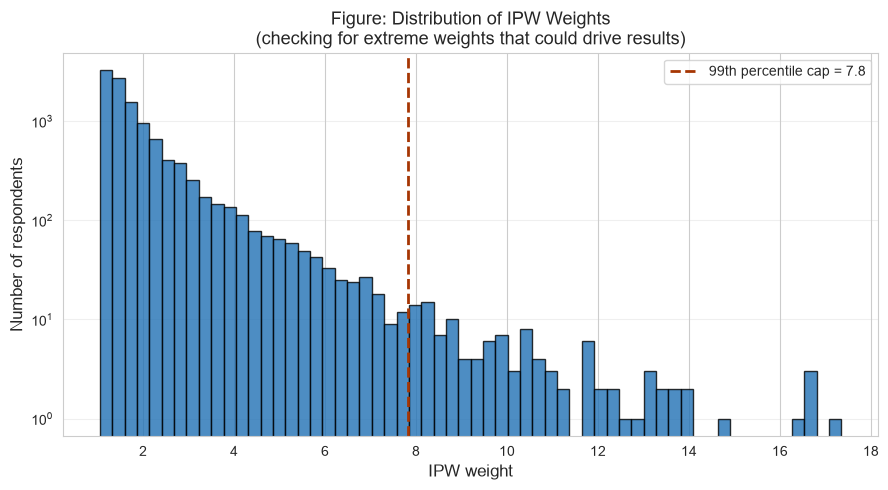

How to read this plot:
- A histogram of IPW weights, shown on a log scale because weights can be very skewed.
- The dashed orange line marks the 99th-percentile weight cap used in the sensitivity check.
- A few very large weights would dominate the ATE; this plot checks that no single weight drives the result.


In [18]:
# ---------------------------------------------------------------------------
# IPW WEIGHT DISTRIBUTION (Modules 7-8)
# ---------------------------------------------------------------------------
# Extreme weights can dominate the IPW estimate. This histogram shows the
# distribution of weights and marks the 99th-percentile cap used in the
# sensitivity check.
# ---------------------------------------------------------------------------
weight_cap = df_support["ipw_weight"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_support["ipw_weight"], bins=60, color="#2171b5", edgecolor="black", alpha=0.8)
ax.axvline(weight_cap, color="#a63603", linestyle="--", linewidth=2,
           label=f"99th percentile cap = {weight_cap:.1f}")
ax.set_xlabel("IPW weight", fontsize=12)
ax.set_ylabel("Number of respondents", fontsize=12)
ax.set_title("Figure: Distribution of IPW Weights\n(checking for extreme weights that could drive results)", fontsize=13)
ax.legend(fontsize=10)
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print('How to read this plot:')
print('- A histogram of IPW weights, shown on a log scale because weights can be very skewed.')
print('- The dashed orange line marks the 99th-percentile weight cap used in the sensitivity check.')
print('- A few very large weights would dominate the ATE; this plot checks that no single weight drives the result.')


## Modules 7–8: Causal Effect Estimation

We estimate the ATE with two methods:

1. **IPW** reweights observations so treated and control groups look comparable on observed confounders.
2. **AIPW** combines IPW with an outcome regression. It is **doubly robust**: it remains consistent if either the propensity model or the outcome model is reasonable.

Both target $ATE = E[Y(1) - Y(0)]$ under the identification assumptions stated earlier.

> **Why this matters:** This is where the DAG's logic becomes a number. IPW and AIPW implement the back-door adjustment justified earlier.

In [19]:
# ---------------------------------------------------------------------------
# IPW ESTIMATOR FOR THE ATE
# ---------------------------------------------------------------------------
# Inverse Probability Weighting creates a pseudo-population in which each
# respondent's observed outcome is weighted up to represent the counterfactual
# group they did not experience.
#   Treated weight:    1 / e(X)
#   Control weight:    1 / (1 - e(X))
# The weighted means estimate E[Y(1)] and E[Y(0)], and their difference is the
# ATE.  This is the pre-specified alternative estimator in the project.
# ---------------------------------------------------------------------------

def estimate_ate_ipw(data, ps_col="propensity", treatment_col="T", outcome_col="Y"):
    """Horvitz-Thompson style IPW ATE estimator."""
    ps = data[ps_col].values
    T = data[treatment_col].values
    Y = data[outcome_col].values
    
    w = np.where(T == 1, 1 / ps, 1 / (1 - ps))
    
    mu1 = np.sum(w * T * Y) / np.sum(w * T)
    mu0 = np.sum(w * (1 - T) * Y) / np.sum(w * (1 - T))
    ate = mu1 - mu0
    return ate, mu1, mu0

ipw_ate, ipw_mu1, ipw_mu0 = estimate_ate_ipw(df_support)

print("=== IPW ESTIMATE ===")
print(f"E[Y(1)] (counterfactual treated mean):  {ipw_mu1*100:.2f}%")
print(f"E[Y(0)] (counterfactual control mean):  {ipw_mu0*100:.2f}%")
print(f"ATE (percentage points):                {ipw_ate*100:.2f} pp")

=== IPW ESTIMATE ===
E[Y(1)] (counterfactual treated mean):  92.93%
E[Y(0)] (counterfactual control mean):  80.08%
ATE (percentage points):                12.85 pp


In [20]:
# ---------------------------------------------------------------------------
# AIPW (DOUBLY ROBUST) ESTIMATOR FOR THE ATE
# ---------------------------------------------------------------------------
# Augmented IPW combines IPW with an outcome regression.  It is called
# "doubly robust" because it remains consistent if EITHER the propensity model
# OR the outcome model is correctly specified (not necessarily both).  This is
# the primary estimator used in the project.
#
# The estimator uses an influence function:
#   IF_1 = (T/e(X)) * (Y - mu(1,X)) + mu(1,X)
#   IF_0 = ((1-T)/(1-e(X))) * (Y - mu(0,X)) + mu(0,X)
#   ATE  = mean(IF_1) - mean(IF_0)
# The standard error is derived from the empirical variance of the influence.
# ---------------------------------------------------------------------------

def estimate_ate_aipw(data, X_vars, treatment_col="T", outcome_col="Y", ps_col="propensity", seed=SEED):
    """
    Augmented IPW estimator using logistic propensity and logistic outcome models.
    Returns ATE, potential-outcome means, and influence-function standard error.
    """
    X = data[X_vars].values
    T = data[treatment_col].values
    Y = data[outcome_col].values
    ps = data[ps_col].values
    n = len(data)
    
    # Outcome model: E[Y | T, X]
    X_out = np.column_stack([T, X])
    out_model = LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs", max_iter=1000, random_state=seed
    )
    out_model.fit(X_out, Y)
    
    # Predict potential outcomes under T=1 and T=0 for everyone
    X1 = np.column_stack([np.ones(n), X])
    X0 = np.column_stack([np.zeros(n), X])
    mu1_x = out_model.predict_proba(X1)[:, 1]
    mu0_x = out_model.predict_proba(X0)[:, 1]
    
    # AIPW influence-function components
    if1 = (T / ps) * (Y - mu1_x) + mu1_x
    if0 = ((1 - T) / (1 - ps)) * (Y - mu0_x) + mu0_x
    
    ate = if1.mean() - if0.mean()
    
    # Influence-function based standard error
    influence = (if1 - if0) - ate
    se = math.sqrt((influence ** 2).sum() / (n ** 2))
    
    return ate, if1.mean(), if0.mean(), se

aipw_ate, aipw_mu1, aipw_mu0, aipw_se = estimate_ate_aipw(df_support, X_vars)
aipw_ci_lower = aipw_ate - 1.96 * aipw_se
aipw_ci_upper = aipw_ate + 1.96 * aipw_se

print("=== AIPW ESTIMATE (PRIMARY) ===")
print(f"E[Y(1)] (counterfactual treated mean):  {aipw_mu1*100:.2f}%")
print(f"E[Y(0)] (counterfactual control mean):  {aipw_mu0*100:.2f}%")
print(f"ATE (percentage points):                {aipw_ate*100:.2f} pp")
print(f"95% confidence interval:                [{aipw_ci_lower*100:.2f}%, {aipw_ci_upper*100:.2f}%]")

estimates = {
    "unadjusted": unadjusted,
    "ipw": {"estimate": ipw_ate, "mu1": ipw_mu1, "mu0": ipw_mu0},
    "aipw": {"estimate": aipw_ate, "mu1": aipw_mu1, "mu0": aipw_mu0,
             "ci_lower": aipw_ci_lower, "ci_upper": aipw_ci_upper, "se": aipw_se},
}

=== AIPW ESTIMATE (PRIMARY) ===


E[Y(1)] (counterfactual treated mean):  93.02%
E[Y(0)] (counterfactual control mean):  79.85%
ATE (percentage points):                13.17 pp
95% confidence interval:                [11.73%, 14.61%]


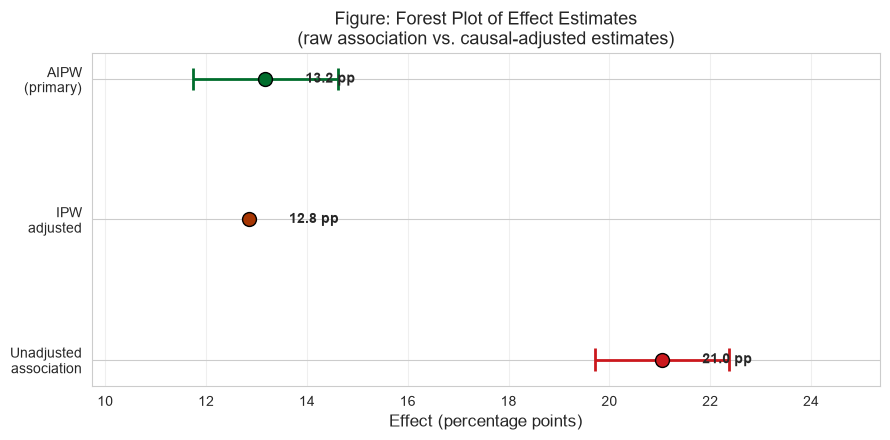

Interpretation: The adjusted estimates are smaller than the raw association, suggesting that observed confounders explain part of the gap.
How to read this plot:
- Each row is an estimate of the effect of having an emergency fund.
- The dot is the point estimate in percentage points.
- The horizontal line is the 95% confidence interval.
- The vertical dashed line at 0 means no effect.
- If an interval crosses 0, the estimate is not statistically significant.
- IPW and AIPW adjust for confounders, so they are closer to a causal effect than the unadjusted association.


In [21]:
# ---------------------------------------------------------------------------
# FOREST PLOT: UNADJUSTED, IPW, AND AIPW ESTIMATES (Modules 7-8)
# ---------------------------------------------------------------------------
# A forest plot compares the point estimates and uncertainty intervals on one
# horizontal axis. It makes it easy to see how adjusting for confounders
# changes both the size and precision of the estimated effect.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

methods = ["Unadjusted\nassociation", "IPW\nadjusted", "AIPW\n(primary)"]
estimates_pp = [
    unadjusted["estimate"] * 100,
    ipw_ate * 100,
    aipw_ate * 100,
]
cis = [
    (unadjusted["ci_lower"] * 100, unadjusted["ci_upper"] * 100),
    (None, None),
    (aipw_ci_lower * 100, aipw_ci_upper * 100),
]
colors = ["#cb181d", "#a63603", "#006d2c"]

y_pos = np.arange(len(methods))
for i, (method, est, ci, color) in enumerate(zip(methods, estimates_pp, cis, colors)):
    ax.scatter(est, i, s=100, color=color, zorder=3, edgecolor="black")
    if ci[0] is not None:
        ax.hlines(i, ci[0], ci[1], color=color, linewidth=2)
        ax.vlines(ci[0], i - 0.08, i + 0.08, color=color, linewidth=2)
        ax.vlines(ci[1], i - 0.08, i + 0.08, color=color, linewidth=2)
    ax.text(est + 0.8, i, f"{est:.1f} pp", va="center", fontsize=10, fontweight="bold")

ax.axvline(0, color="#636363", linestyle="-", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel("Effect (percentage points)", fontsize=12)
ax.set_title("Figure: Forest Plot of Effect Estimates\n(raw association vs. causal-adjusted estimates)", fontsize=13)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(min(unadjusted["ci_lower"] * 100, aipw_ci_lower * 100) - 2,
            max(unadjusted["ci_upper"] * 100, aipw_ci_upper * 100) + 3)
plt.tight_layout()
plt.show()

print("Interpretation: The adjusted estimates are smaller than the raw association, "
      "suggesting that observed confounders explain part of the gap.")

print("How to read this plot:")
print("- Each row is an estimate of the effect of having an emergency fund.")
print("- The dot is the point estimate in percentage points.")
print("- The horizontal line is the 95% confidence interval.")
print("- The vertical dashed line at 0 means no effect.")
print("- If an interval crosses 0, the estimate is not statistically significant.")
print("- IPW and AIPW adjust for confounders, so they are closer to a causal effect than the unadjusted association.")


## Modules 7–8: Counterfactual Interpretation

The ATE answers a **what-if** question: *If we could give everyone an emergency fund, how would the bill-payment rate change compared with a world where no one had one?*

Under the stated assumptions, the model estimates two potential-outcome means:
- $E[Y(1)]$: estimated bill-payment rate if everyone had a fund.
- $E[Y(0)]$: estimated rate if no one had a fund.

This is **not** a guarantee for any one person and **not** financial advice. It is a group-level estimate under assumptions.

> **Why this matters:** Counterfactuals are the heart of causality. We are not just comparing groups; we are estimating what the same population would look like under two different policies.

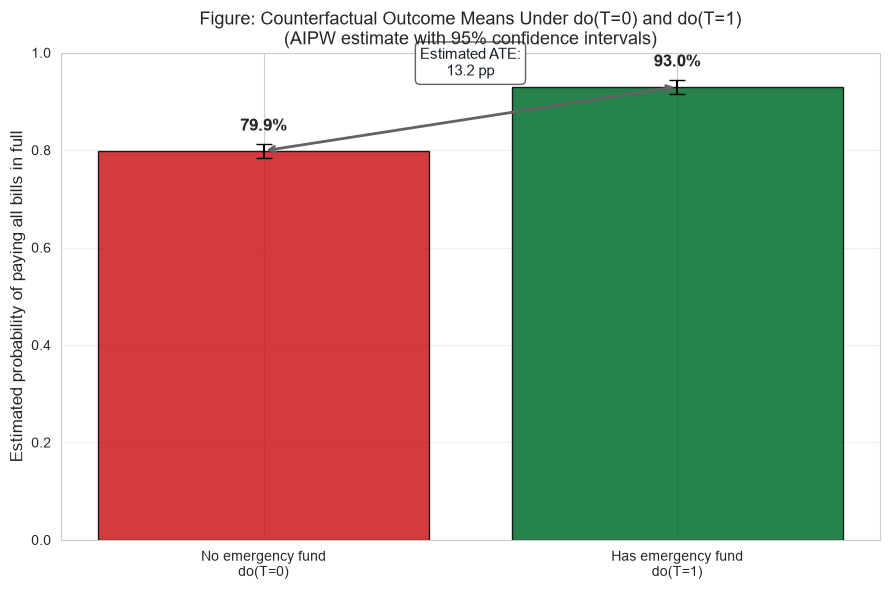

AIPW ATE = 13.17 percentage points (95% CI: 11.73% to 14.61%)
How to read this plot:
- Two bars show estimated bill-payment rates under two hypothetical policies.
- Left bar: estimated rate if NO ONE had a three-month emergency fund, do(T=0).
- Right bar: estimated rate if EVERYONE had a three-month emergency fund, do(T=1).
- The error bars are 95% confidence intervals.
- The double-headed arrow shows the estimated ATE in percentage points.


In [22]:
# ---------------------------------------------------------------------------
# VISUALIZE THE COUNTERFACTUAL CONTRAST WITH UNCERTAINTY (Modules 7-8)
# ---------------------------------------------------------------------------
# This bar chart translates the ATE into the two potential-outcome means.
# E[Y(1)] is the estimated bill-payment rate if everyone had an emergency fund;
# E[Y(0)] is the estimated rate if no one had one. The gap between them is
# the estimated average causal effect. Error bars come from the AIPW standard error.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

labels = ["No emergency fund\ndo(T=0)", "Has emergency fund\ndo(T=1)"]
means = [aipw_mu0, aipw_mu1]
errs = [1.96 * aipw_se, 1.96 * aipw_se]
colors = ["#cb181d", "#006d2c"]

bars = ax.bar(labels, means, yerr=errs, color=colors, edgecolor="black", alpha=0.85, capsize=6)
ax.set_ylabel("Estimated probability of paying all bills in full", fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Figure: Counterfactual Outcome Means Under do(T=0) and do(T=1)\n(AIPW estimate with 95% confidence intervals)", fontsize=13)

for bar, mean, err in zip(bars, means, errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.02,
            f"{mean*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.annotate("", xy=(1, aipw_mu1), xytext=(0, aipw_mu0),
            arrowprops=dict(arrowstyle="<->", color="#636363", lw=2))
ax.text(0.5, (aipw_mu1 + aipw_mu0)/2 + 0.08,
        f"Estimated ATE:\n{aipw_ate*100:.1f} pp",
        ha="center", va="bottom", fontsize=11, color="#17202A",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#636363"))

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AIPW ATE = {aipw_ate*100:.2f} percentage points (95% CI: {aipw_ci_lower*100:.2f}% to {aipw_ci_upper*100:.2f}%)")

print('How to read this plot:')
print('- Two bars show estimated bill-payment rates under two hypothetical policies.')
print('- Left bar: estimated rate if NO ONE had a three-month emergency fund, do(T=0).')
print('- Right bar: estimated rate if EVERYONE had a three-month emergency fund, do(T=1).')
print('- The error bars are 95% confidence intervals.')
print('- The double-headed arrow shows the estimated ATE in percentage points.')


In [23]:
print("Starting Module 9: Identification Assumptions within Pearl's Causal Hierarchy")

Starting Module 9: Identification Assumptions within Pearl's Causal Hierarchy


## Module 9: Identification Assumptions

Causal inference from observational data requires explicit assumptions. We state them so they can be questioned.

1. **Consistency**: the treatment is well-defined and the observed outcome equals the potential outcome under the observed treatment.
2. **Conditional exchangeability**: given the measured confounders, treatment is independent of potential outcomes. *Threat*: unmeasured financial shocks or financial literacy.
3. **Positivity**: every respondent has a non-zero chance of being treated or untreated within each covariate stratum.
4. **SUTVA**: one person's emergency-fund status does not affect another's bill-payment outcome.
5. **Temporal ordering**: the weakest assumption. Both variables come from the same interview, so reverse causality is plausible.
6. **Measurement validity**: SHED responses map correctly to the codebook.

> **Why this matters:** Causal conclusions are only as strong as the assumptions behind them. Stating them explicitly lets a reader challenge them.

In [24]:
print("Completed Module 9: Identification Assumptions within Pearl's Causal Hierarchy")

Completed Module 9: Identification Assumptions within Pearl's Causal Hierarchy


## Module 10: Robustness Checks and Sensitivity Analysis

Causal estimates should be checked for stability. We examine:

1. **Weight truncation**: do extreme IPW weights change the estimate?
2. **E-value**: how strong would an unmeasured confounder need to be to fully explain away the observed effect?

These checks quantify robustness; they do not prove causality.

> **Why this matters:** Sensitivity analysis asks: *How wrong would our assumptions have to be before the conclusion flips?* That question is more useful than pretending the answer is certain.

=== WEIGHT-STABILITY SENSITIVITY ===
Weight cap quantile:              0.99
Weight cap value:                 7.82
Max uncapped weight:              17.35
IPW ATE (uncapped):               12.85 pp
IPW ATE (capped at 0.99 quantile):  13.44 pp
Difference:                       0.59 pp

=== E-VALUE SENSITIVITY ===
Risk ratio (point):               1.165
E-value (point estimate):         1.603
E-value (lower CI):               1.504

Interpretation: An unmeasured confounder would need to be associated with both
treatment and outcome by a risk-ratio of at least the E-value to fully explain
away the observed effect, conditional on the measured covariates.


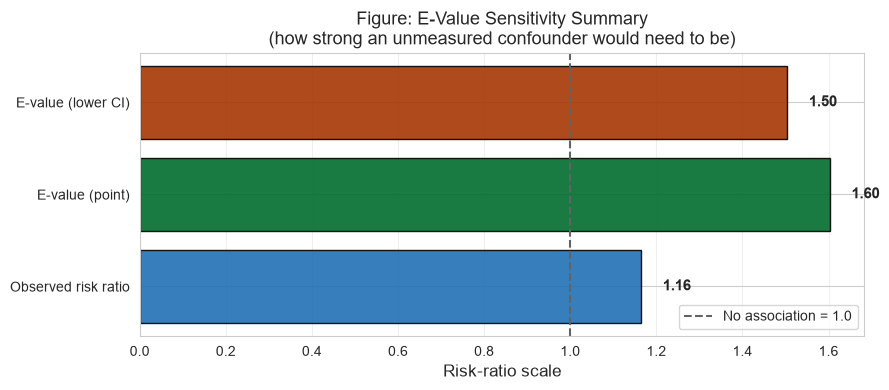

Completed Module 10: Robustness Checks, Sensitivity, and Reporting
How to read this plot:
- Three bars on a risk-ratio scale. Risk ratio = 1 means no association.
- Observed risk ratio: how much more likely the treated group is to pay all bills, from the AIPW estimate.
- E-value (point): the minimum risk-ratio an unmeasured confounder would need with both treatment AND outcome to fully explain the effect.
- E-value (lower CI): the same threshold applied to the lower confidence bound, a more conservative benchmark.
- Higher E-values mean a stronger unmeasured factor would be required to overturn the result.


In [25]:
# ---------------------------------------------------------------------------
# ROBUSTNESS AND SENSITIVITY ANALYSIS (Module 10 start)
# ---------------------------------------------------------------------------
# Any causal estimate should be checked for stability.  We examine:
#   1. Weight truncation: do a few extreme IPW weights drive the result?
#   2. E-value: how strong would an unmeasured confounder have to be to fully
#      explain away the observed effect?
# These checks quantify robustness; they do not prove causality.
# ---------------------------------------------------------------------------

# --- 1. Weight-stability sensitivity ---
WEIGHT_CAP_QUANTILE = 0.99
weight_cap = df_support["ipw_weight"].quantile(WEIGHT_CAP_QUANTILE)
df_support["ipw_weight_capped"] = df_support["ipw_weight"].clip(upper=weight_cap)

def estimate_ate_ipw_weighted(data, weight_col, treatment_col="T", outcome_col="Y"):
    T = data[treatment_col].values
    Y = data[outcome_col].values
    w = data[weight_col].values
    mu1 = np.sum(w * T * Y) / np.sum(w * T)
    mu0 = np.sum(w * (1 - T) * Y) / np.sum(w * (1 - T))
    return mu1 - mu0, mu1, mu0

ipw_uncapped_ate, _, _ = estimate_ate_ipw_weighted(df_support, "ipw_weight")
ipw_capped_ate, _, _ = estimate_ate_ipw_weighted(df_support, "ipw_weight_capped")

print("=== WEIGHT-STABILITY SENSITIVITY ===")
print(f"Weight cap quantile:              {WEIGHT_CAP_QUANTILE}")
print(f"Weight cap value:                 {weight_cap:.2f}")
print(f"Max uncapped weight:              {df_support['ipw_weight'].max():.2f}")
print(f"IPW ATE (uncapped):               {ipw_uncapped_ate*100:.2f} pp")
print(f"IPW ATE (capped at {WEIGHT_CAP_QUANTILE} quantile):  {ipw_capped_ate*100:.2f} pp")
print(f"Difference:                       {(ipw_capped_ate - ipw_uncapped_ate)*100:.2f} pp")

# --- 2. E-value sensitivity ---
rr_obs = aipw_mu1 / max(aipw_mu0, 1e-10)
e_value_point = rr_obs + math.sqrt(rr_obs * (rr_obs - 1))

mu1_lower = aipw_mu1 - 1.96 * aipw_se
mu0_upper = aipw_mu0 + 1.96 * aipw_se
rr_ci = max(mu1_lower, 1e-10) / max(mu0_upper, 1e-10)
e_value_ci = rr_ci + math.sqrt(rr_ci * (rr_ci - 1)) if rr_ci > 1 else 1.0

print("\n=== E-VALUE SENSITIVITY ===")
print(f"Risk ratio (point):               {rr_obs:.3f}")
print(f"E-value (point estimate):         {e_value_point:.3f}")
print(f"E-value (lower CI):               {e_value_ci:.3f}")
print("\nInterpretation: An unmeasured confounder would need to be associated with both")
print("treatment and outcome by a risk-ratio of at least the E-value to fully explain")
print("away the observed effect, conditional on the measured covariates.")

# --- 3. E-value summary figure ---
fig, ax = plt.subplots(figsize=(9, 4))
labels = ["Observed risk ratio", "E-value (point)", "E-value (lower CI)"]
values = [rr_obs, e_value_point, e_value_ci]
colors = ["#2171b5", "#006d2c", "#a63603"]
bars = ax.barh(labels, values, color=colors, edgecolor="black", alpha=0.9)
ax.axvline(1.0, color="#636363", linestyle="--", linewidth=1.5, label="No association = 1.0")
ax.set_xlabel("Risk-ratio scale", fontsize=12)
ax.set_title("Figure: E-Value Sensitivity Summary\n(how strong an unmeasured confounder would need to be)", fontsize=13)
for bar, val in zip(bars, values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=11, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Completed Module 10: Robustness Checks, Sensitivity, and Reporting")

print('How to read this plot:')
print('- Three bars on a risk-ratio scale. Risk ratio = 1 means no association.')
print('- Observed risk ratio: how much more likely the treated group is to pay all bills, from the AIPW estimate.')
print('- E-value (point): the minimum risk-ratio an unmeasured confounder would need with both treatment AND outcome to fully explain the effect.')
print('- E-value (lower CI): the same threshold applied to the lower confidence bound, a more conservative benchmark.')
print('- Higher E-values mean a stronger unmeasured factor would be required to overturn the result.')


## Module 10: Summary of Findings

The table below collects the main numerical results in one place.

> **Why this matters:** A long notebook can obscure the bottom line. The summary ties the causal question back to the sample, diagnostics, and final effect estimate so a reader can verify the chain of reasoning at a glance.

In [26]:
# ---------------------------------------------------------------------------
# SUMMARY OF FINDINGS
# ---------------------------------------------------------------------------
# We collect the main numerical results into one table.  This makes it easy
# for a reader to verify the sample, the diagnostics, and the effect
# estimates at a glance.  We also save a machine-readable JSON summary for
# provenance and reproducibility.
# ---------------------------------------------------------------------------
summary_records = [
    {"Item": "Raw SHED 2023 records", "Value": f"{sample_meta['raw_n']:,}"},
    {"Item": "Analytic sample", "Value": f"{sample_meta['analytic_n']:,}"},
    {"Item": "Support-retained sample", "Value": f"{ps_diag['n_support']:,}"},
    {"Item": "Treated (has emergency fund)", "Value": f"{sample_meta['treated_n']:,}"},
    {"Item": "Control (no emergency fund)", "Value": f"{sample_meta['control_n']:,}"},
    {"Item": "Unadjusted association", "Value": f"{unadjusted['estimate']*100:.2f} pp (95% CI: {unadjusted['ci_lower']*100:.2f}%, {unadjusted['ci_upper']*100:.2f}%)"},
    {"Item": "IPW adjusted ATE", "Value": f"{ipw_ate*100:.2f} pp"},
    {"Item": "AIPW primary ATE", "Value": f"{aipw_ate*100:.2f} pp (95% CI: {aipw_ci_lower*100:.2f}%, {aipw_ci_upper*100:.2f}%)"},
    {"Item": "Counterfactual E[Y(1)]", "Value": f"{aipw_mu1*100:.2f}%"},
    {"Item": "Counterfactual E[Y(0)]", "Value": f"{aipw_mu0*100:.2f}%"},
    {"Item": "Max |SMD| before weighting", "Value": f"{max_smd_before:.3f}"},
    {"Item": "Max |SMD| after weighting", "Value": f"{max_smd_after:.3f}"},
    {"Item": "All covariates balanced (<0.10)", "Value": str(all_balanced)},
    {"Item": "E-value (point estimate)", "Value": f"{e_value_point:.3f}"},
    {"Item": "E-value (lower CI)", "Value": f"{e_value_ci:.3f}"},
]

summary_df = pd.DataFrame(summary_records)
display(summary_df)

# Save a JSON summary in the notebook folder for traceability
summary_out = {
    "project": "Emergency Fund and Household Bill Payment Causal AI Capstone",
    "data_status": "empirical",
    "survey_wave": "SHED 2023",
    "design": "Cross-sectional",
    **sample_meta,
    "propensity_support": ps_diag,
    "balance": {"max_smd_before": max_smd_before, "max_smd_after": max_smd_after, "all_balanced": all_balanced},
    "estimates": {
        "unadjusted": {k: float(v) for k, v in unadjusted.items()},
        "ipw": {k: float(v) for k, v in estimates["ipw"].items()},
        "aipw": {k: float(v) for k, v in estimates["aipw"].items()},
    },
    "sensitivity": {
        "e_value_point": e_value_point,
        "e_value_lower_ci": e_value_ci,
        "ipw_uncapped_ate_pp": ipw_uncapped_ate * 100,
        "ipw_capped_ate_pp": ipw_capped_ate * 100,
    },
}

summary_path = NOTEBOOK_DIR / "NOTEBOOK" / "notebook_summary.json"
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, "w") as f:
    json.dump(summary_out, f, indent=2, default=str)

print(f"\nSummary saved to: {summary_path}")

,Item,Value
0,Raw SHED 2023 records,"11,400"
1,Analytic sample,"11,400"
2,Support-retained sample,"11,400"
3,Treated (has emergency fund),"6,482"
4,Control (no emergency fund),"4,918"
5,Unadjusted association,"21.04 pp (95% CI: 19.72%, 22.37%)"
6,IPW adjusted ATE,12.85 pp
7,AIPW primary ATE,"13.17 pp (95% CI: 11.73%, 14.61%)"
8,Counterfactual E[Y(1)],93.02%
9,Counterfactual E[Y(0)],79.85%



Summary saved to: C:\Users\rueen\Documents\SCHOOL\UOFT\ADVANCED_ARTIFICIAL_INTELLIGENCE\4107_Probabilistic_Programming_and_Causal_AI\FINAL_PROJ_CAUSAL_AI_EMERG_FUNDS_BILL_PAY\NOTEBOOK\NOTEBOOK\notebook_summary.json


## Module 10: Exploratory Subgroup Analysis

Subgroup analyses are **pre-specified and exploratory**. They are not used to select the primary result and should be interpreted cautiously because sample sizes are smaller.

We look at income tier (`PPINCIMP`) and age band (`PPAGE`).

> **Why this matters:** Effects may differ by income or age, but subgroup analyses are easy to overinterpret. We treat them as hypothesis-generating, not hypothesis-confirming.

In [27]:
# ---------------------------------------------------------------------------
# PRE-SPECIFIED EXPLORATORY SUBGROUP ANALYSIS
# ---------------------------------------------------------------------------
# Subgroup effects are estimated only to describe possible heterogeneity.
# They are NOT used to select the primary conclusion.  We limit ourselves to
# two substantively motivated subgroups defined before seeing results:
# income tier and age band.
# ---------------------------------------------------------------------------

# Income tier: use the numeric PPINCIMP directly (1 = lowest, 7 = highest).
df_support["income_tier"] = df_support["PPINCIMP"].astype(int)

# Age band: cut the continuous age variable into three policy-relevant groups.
def age_band(age):
    if age < 35:
        return "18-34"
    elif age < 55:
        return "35-54"
    else:
        return "55+"

df_support["age_band"] = df_support["PPAGE"].apply(age_band)

def estimate_subgroup_ates(data, subgroup_col):
    """Estimate AIPW ATE within each level of subgroup_col."""
    results = []
    for level, sub in data.groupby(subgroup_col):
        # Skip very small subgroups or subgroups with only one treatment level
        if len(sub) < 50 or sub["T"].nunique() < 2:
            continue
        try:
            ate, mu1, mu0, se = estimate_ate_aipw(sub, X_vars, seed=SEED)
            results.append({
                "subgroup": str(level),
                "n": len(sub),
                "treated": int(sub["T"].sum()),
                "control": int((sub["T"] == 0).sum()),
                "ate_pp": ate * 100,
                "ci_lower_pp": (ate - 1.96 * se) * 100,
                "ci_upper_pp": (ate + 1.96 * se) * 100,
            })
        except Exception as exc:
            print(f"Subgroup {level} failed: {exc}")
    return pd.DataFrame(results)

income_results = estimate_subgroup_ates(df_support, "income_tier").sort_values("subgroup")
age_results = estimate_subgroup_ates(df_support, "age_band").sort_values("subgroup")

print("=== SUBGROUP ATEs BY INCOME TIER ===")
display(income_results.round(2))

print("\n=== SUBGROUP ATEs BY AGE BAND ===")
display(age_results.round(2))

=== SUBGROUP ATEs BY INCOME TIER ===


,subgroup,n,treated,control,ate_pp,ci_lower_pp,ci_upper_pp
0,1,461,83,378,21.17,8.07,34.27
1,2,911,249,662,19.39,13.48,25.29
2,3,1860,734,1126,17.12,13.41,20.83
3,4,1828,984,844,14.25,11.20,17.30
4,5,1579,948,631,12.92,9.40,16.44
5,6,2125,1414,711,9.61,6.66,12.56
6,7,2636,2070,566,9.10,6.42,11.78



=== SUBGROUP ATEs BY AGE BAND ===


,subgroup,n,treated,control,ate_pp,ci_lower_pp,ci_upper_pp
0,18-34,2456,1055,1401,13.17,9.6,16.75
1,35-54,3523,1775,1748,15.22,12.5,17.93
2,55+,5421,3652,1769,10.70,8.9,12.49


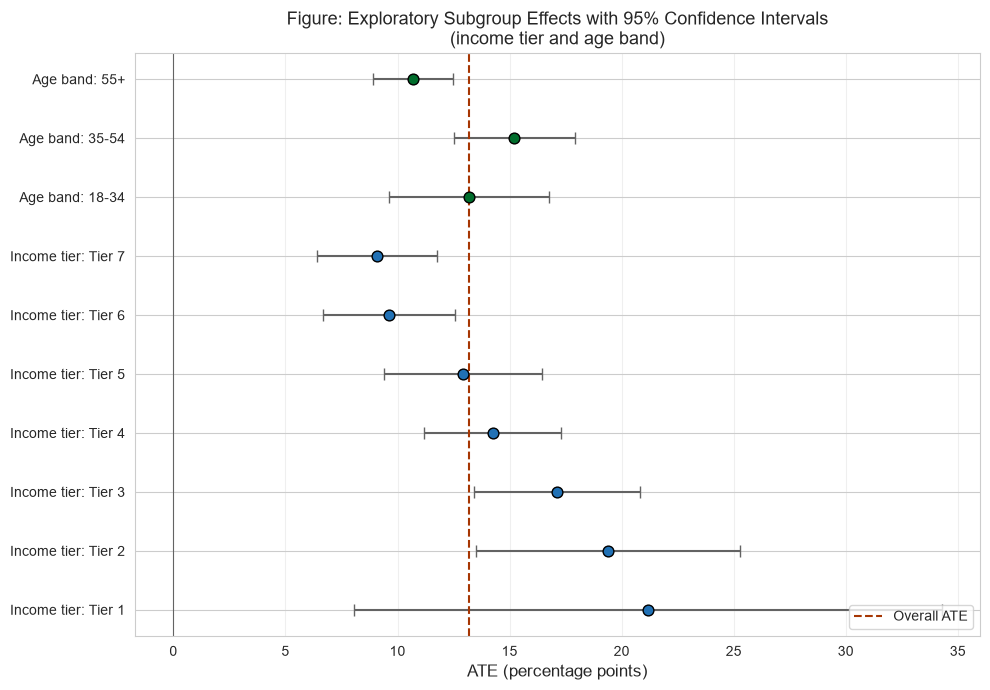

How to read this plot:
- Each dot is an exploratory subgroup ATE estimate.
- The horizontal line through each dot is the 95% confidence interval.
- Blue dots are income tiers; green dots are age bands.
- The dashed orange vertical line is the overall ATE from the primary analysis.
- Wider intervals mean more uncertainty, which is expected in smaller subgroups.
- These are exploratory; do not choose or report subgroups based on preferred effect sizes.


In [28]:
# ---------------------------------------------------------------------------
# COMBINED FOREST PLOT: SUBGROUP EFFECTS (Module 10)
# ---------------------------------------------------------------------------
# This single forest plot shows exploratory subgroup ATEs for income tier and
# age band, with the overall ATE as a vertical reference. It is easier to read
# than two separate plots and makes it clear that subgroup analyses are
# exploratory and have wider uncertainty intervals.
# ---------------------------------------------------------------------------
# Prepare combined data
income_results["group_type"] = "Income tier"
age_results["group_type"] = "Age band"
combined = pd.concat([income_results, age_results], ignore_index=True)
combined["label"] = combined.apply(
    lambda r: f"{r['group_type']}: Tier {r['subgroup']}" if r["group_type"] == "Income tier"
    else f"{r['group_type']}: {r['subgroup']}", axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(combined))
colors = ["#2171b5" if gt == "Income tier" else "#006d2c" for gt in combined["group_type"]]

ax.errorbar(combined["ate_pp"], y_pos,
            xerr=[combined["ate_pp"] - combined["ci_lower_pp"],
                  combined["ci_upper_pp"] - combined["ate_pp"]],
            fmt="o", color="#636363", ecolor="#636363", capsize=4, markersize=7)
for i, row in combined.iterrows():
    ax.scatter(row["ate_pp"], i, color=colors[i], s=60, zorder=3, edgecolor="black")

ax.axvline(aipw_ate * 100, color="#a63603", linestyle="--", linewidth=1.5, label="Overall ATE")
ax.axvline(0, color="#636363", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(combined["label"], fontsize=10)
ax.set_xlabel("ATE (percentage points)", fontsize=12)
ax.set_title("Figure: Exploratory Subgroup Effects with 95% Confidence Intervals\n(income tier and age band)", fontsize=13)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print("Warning: Subgroup findings are exploratory. Do not select or report based on preferred effect sizes.")

print('How to read this plot:')
print('- Each dot is an exploratory subgroup ATE estimate.')
print('- The horizontal line through each dot is the 95% confidence interval.')
print('- Blue dots are income tiers; green dots are age bands.')
print('- The dashed orange vertical line is the overall ATE from the primary analysis.')
print('- Wider intervals mean more uncertainty, which is expected in smaller subgroups.')
print('- These are exploratory; do not choose or report subgroups based on preferred effect sizes.')


## Module 10: Limitations, Conclusion, and References

### Limitations
1. **Cross-sectional design**: treatment and outcome come from the same interview, so temporal ordering is not established and reverse causality is possible.
2. **Unmeasured confounding**: financial shocks, financial literacy, and other unobserved factors may confound the relationship. The E-value quantifies but does not eliminate this threat.
3. **Self-reported measures**: responses rely on recall and may be mismeasured.
4. **Complete-case selection**: excluding respondents with missing values may introduce selection bias.
5. **SUTVA**: we assume no interference between respondents, which may be violated by household-level decisions.
6. **Generalizability**: results apply to the SHED 2023 analytic population under the stated assumptions.

### Conclusion
Under the identification assumptions encoded in the DAG — and supported by covariate balance, common support, and sensitivity checks — the estimated average causal effect of having a three-month emergency fund on paying all non-credit-card bills in full is reported in the summary table above.

This is a **causal estimate under assumptions**, not a definitive causal fact.

### References
- Board of Governors of the Federal Reserve System. *Report on the Economic Well-Being of U.S. Households (SHED)*. Washington, D.C.: Federal Reserve, 2023.
- SHED 2023 codebook (bundled separately if included).

The raw SHED microdata are used for research purposes only and are not redistributed in this repository.